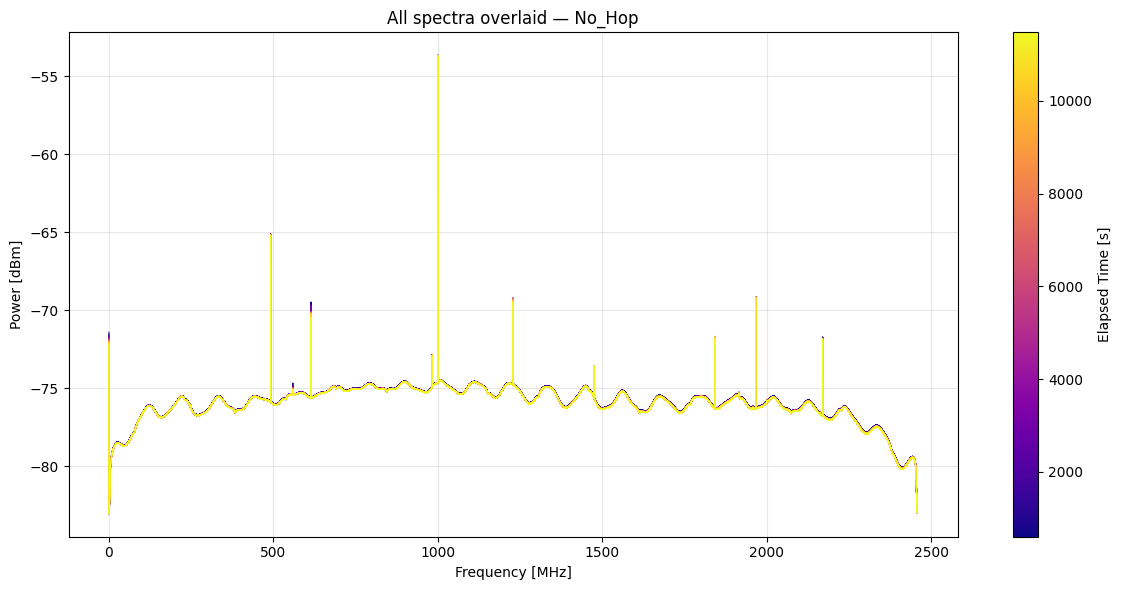

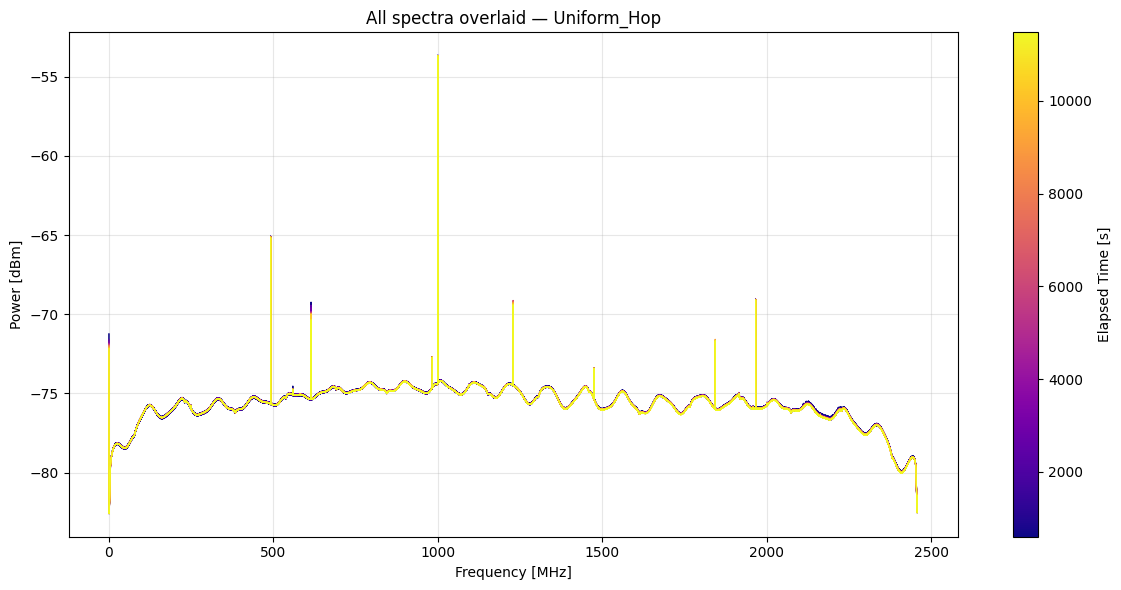

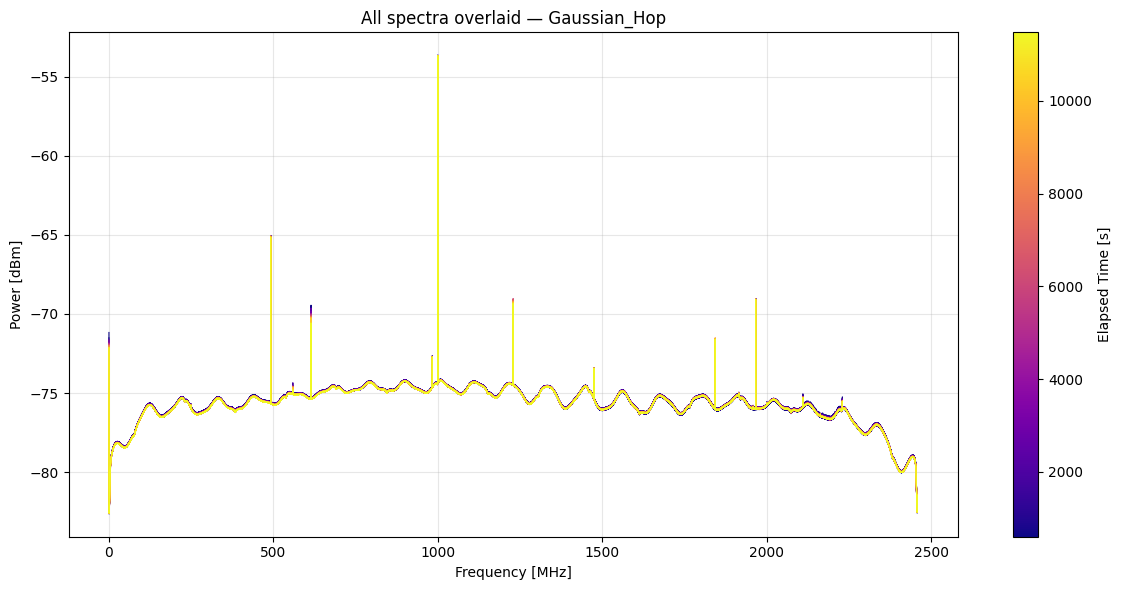

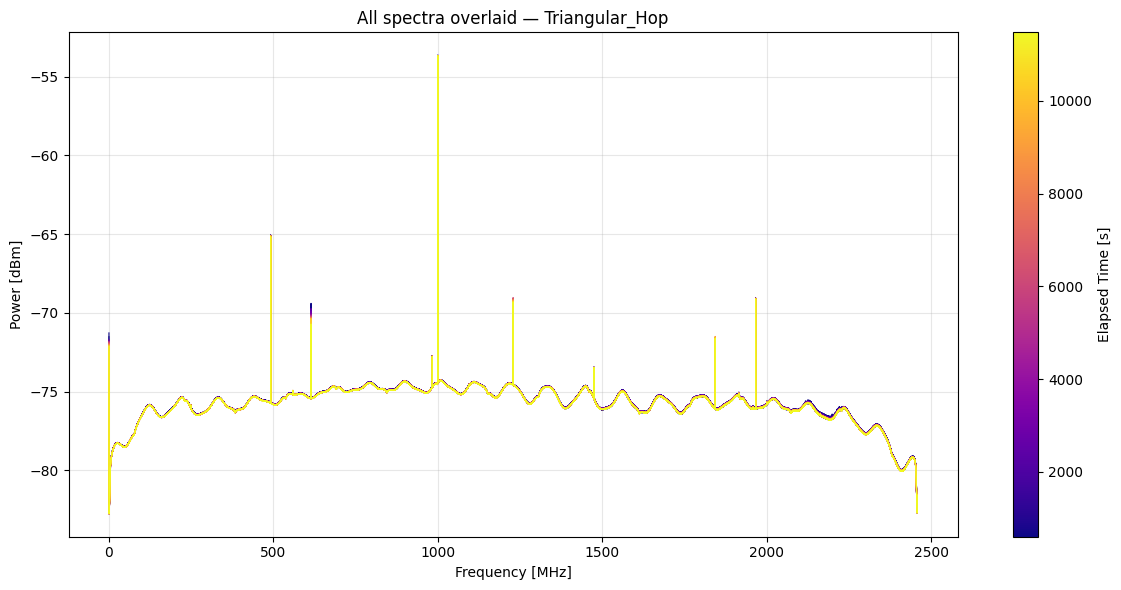

Skipping: .\partial_Cosine2_Hop_11477s_20251125_052139.npz


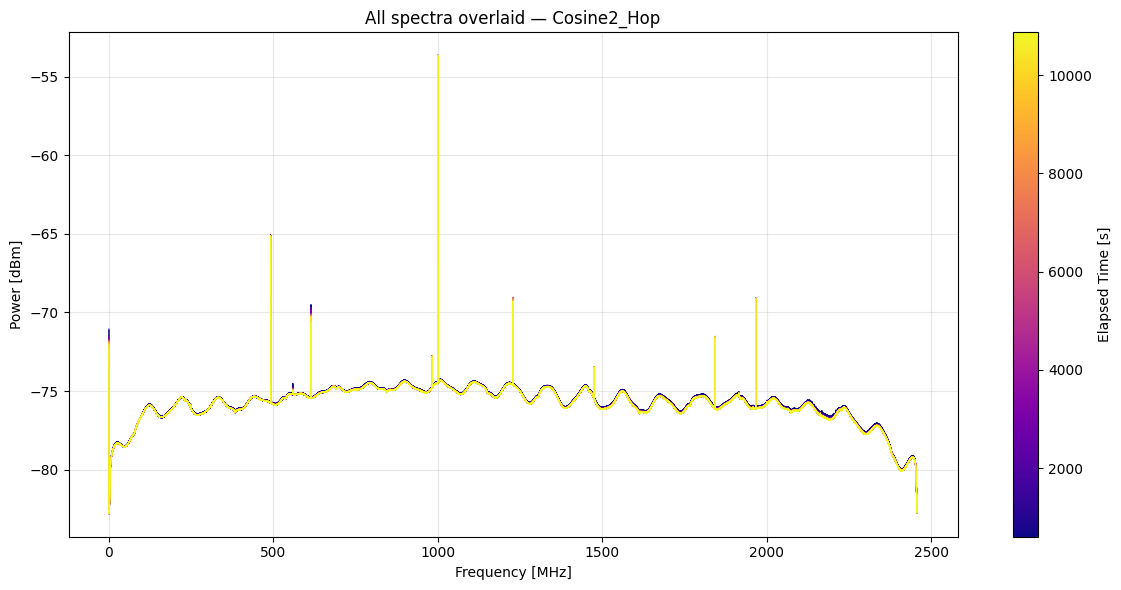

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

path = "./"
method_names = ["No_Hop", "Uniform_Hop", "Gaussian_Hop", "Triangular_Hop", "Cosine2_Hop"]

def load_spectra(method):
    files = sorted(glob.glob(os.path.join(path, f"partial_{method}_*.npz")))
    data = []
    for fn in files:
        try:
            d = np.load(fn)
            data.append((float(d["elapsed_seconds"]), d["F"], d["spec"]))
        except:
            print("Skipping:", fn)
    data.sort(key=lambda x: x[0])
    return data

def to_dBm(spec, R=50):
    return 10*np.log10(np.maximum(spec / (2*R*1e-3), 1e-20))


# =======================================================
# PLOT — overlay spectra with time colormap
# =======================================================
for method in method_names:

    data = load_spectra(method)

    if len(data) == 0:
        print(f"No data for {method}")
        continue

    times = np.array([d[0] for d in data])
    t_min, t_max = times.min(), times.max()
    t_norm = (times - t_min) / (t_max - t_min + 1e-12)

    cmap = plt.cm.plasma

    fig, ax = plt.subplots(figsize=(12,6))
    ax.set_title(f"All spectra overlaid — {method}")

    for (t, F, spec), c in zip(data, cmap(t_norm)):
        ax.plot(F, to_dBm(spec), color=c, linewidth=0.8)

    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Power [dBm]")
    ax.grid(True, alpha=0.3)

    sm = plt.cm.ScalarMappable(cmap=cmap)
    sm.set_array(times)

    cbar = fig.colorbar(sm, ax=ax) 
    cbar.set_label("Elapsed Time [s]")

    fig.tight_layout()
    fig.savefig(f"spectra_overlay_{method}.png", dpi=150)
    plt.show()


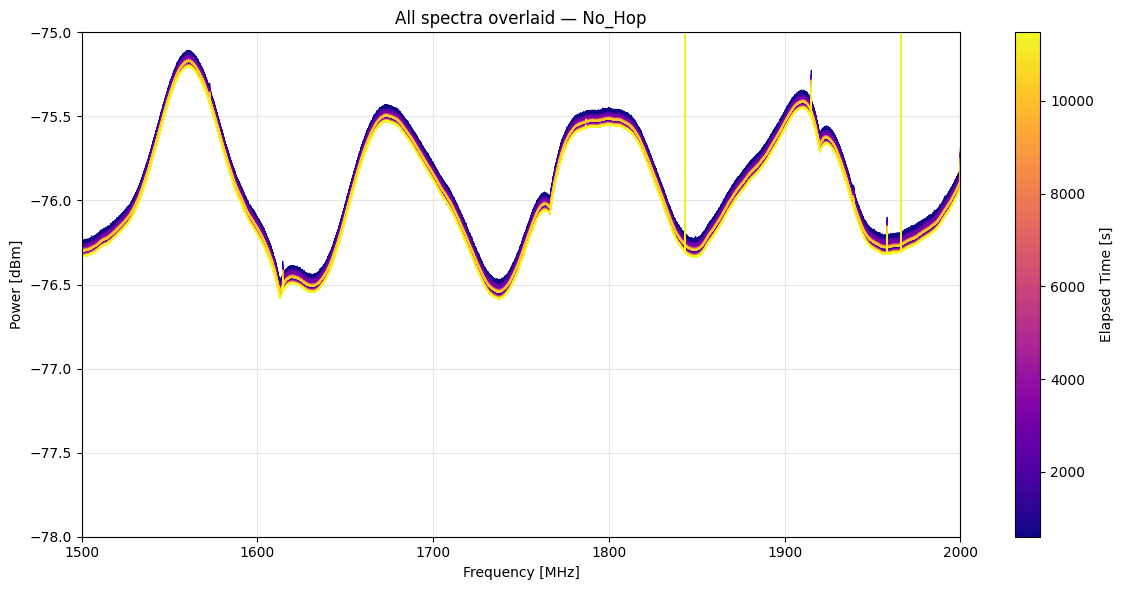

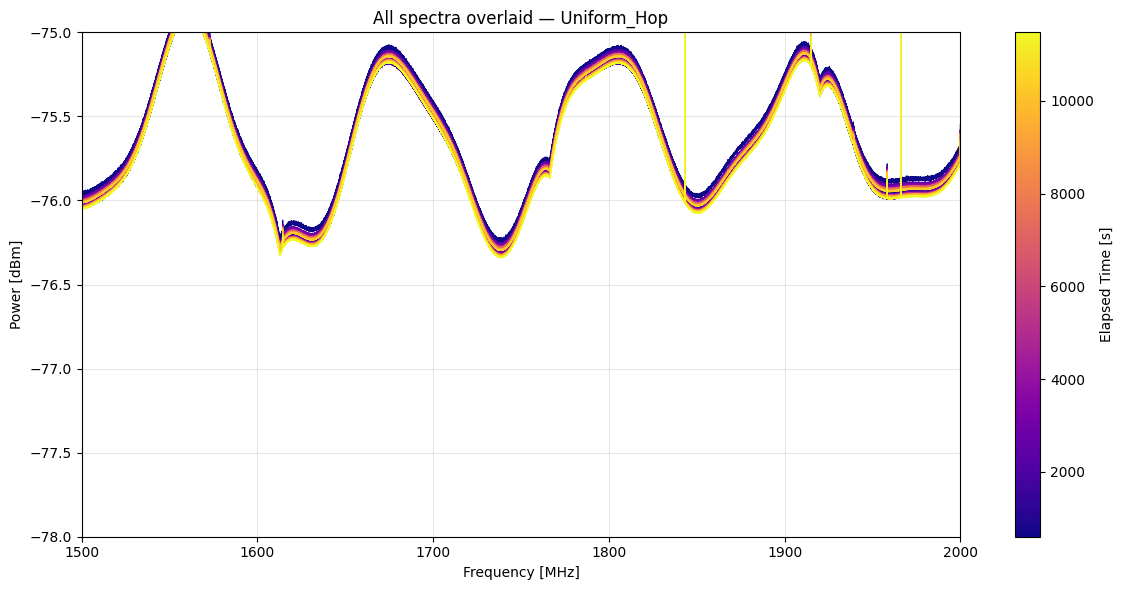

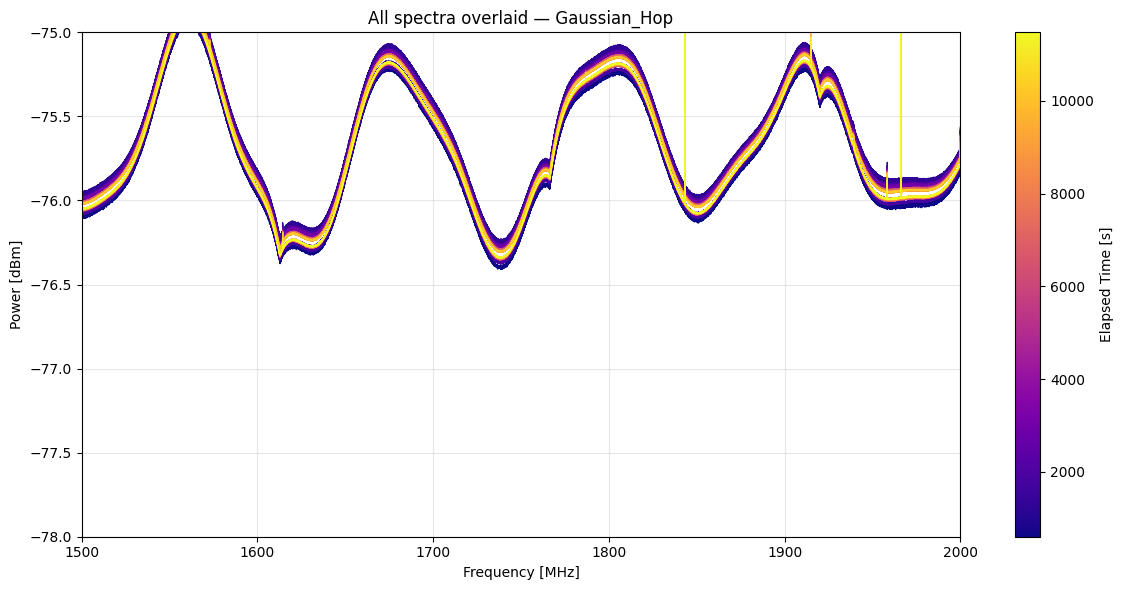

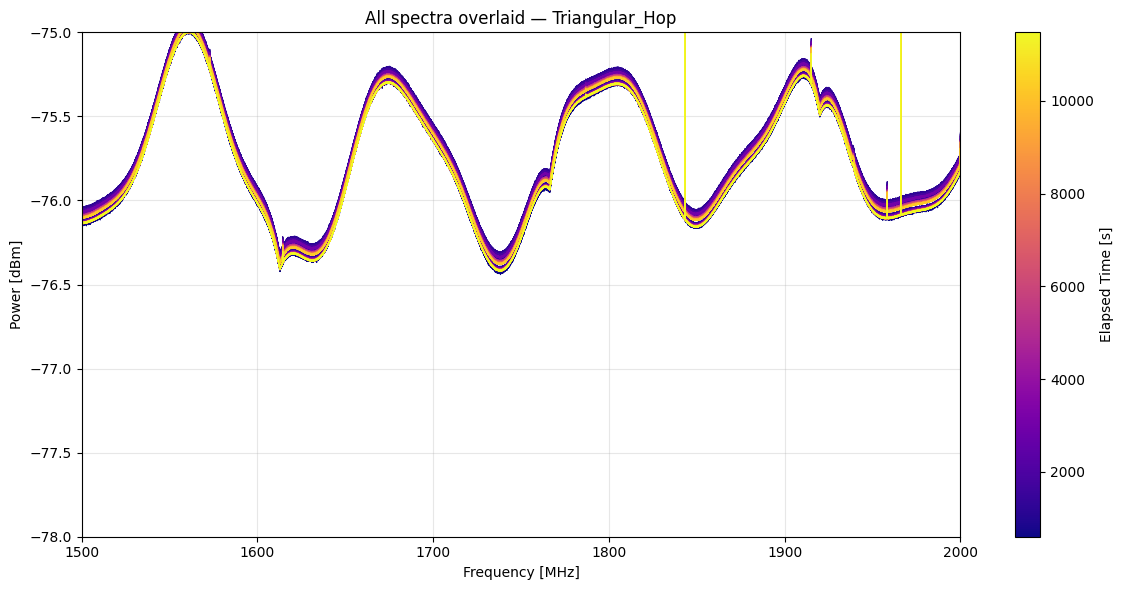

Skipping: .\partial_Cosine2_Hop_11477s_20251125_052139.npz


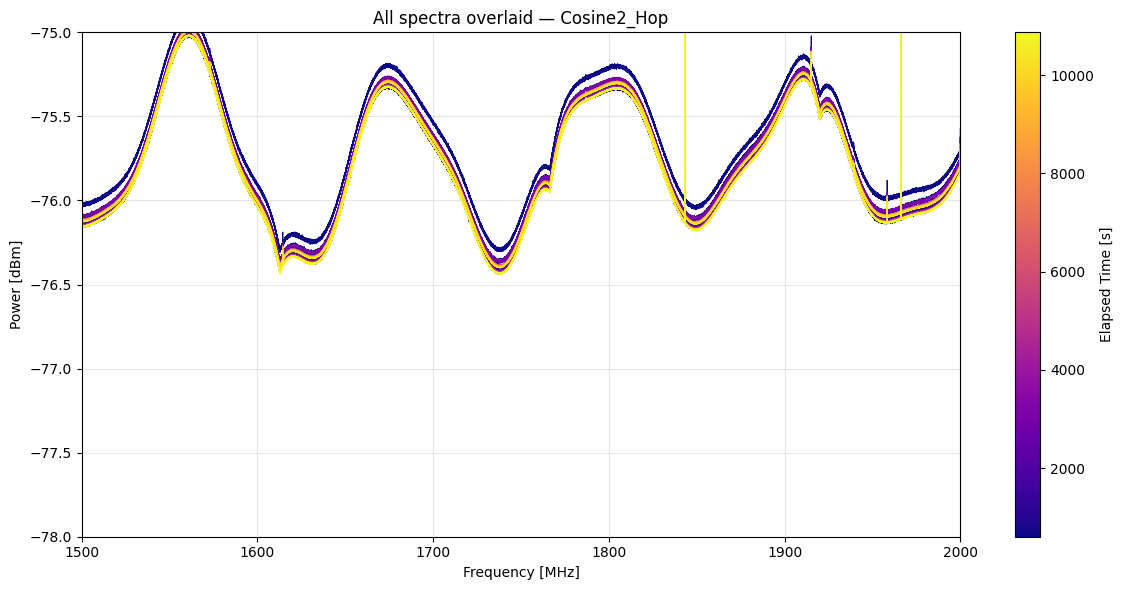

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

path = "./"
method_names = ["No_Hop", "Uniform_Hop", "Gaussian_Hop", "Triangular_Hop", "Cosine2_Hop"]

def load_spectra(method):
    files = sorted(glob.glob(os.path.join(path, f"partial_{method}_*.npz")))
    data = []
    for fn in files:
        try:
            d = np.load(fn)
            data.append((float(d["elapsed_seconds"]), d["F"], d["spec"]))
        except:
            print("Skipping:", fn)
    data.sort(key=lambda x: x[0])
    return data

def to_dBm(spec, R=50):
    return 10*np.log10(np.maximum(spec / (2*R*1e-3), 1e-20))


# =======================================================
# PLOT — overlay spectra with time colormap and zoom
# =======================================================
for method in method_names:

    data = load_spectra(method)

    if len(data) == 0:
        print(f"No data for {method}")
        continue

    times = np.array([d[0] for d in data])
    t_min, t_max = times.min(), times.max()
    t_norm = (times - t_min) / (t_max - t_min + 1e-12)

    cmap = plt.cm.plasma

    fig, ax = plt.subplots(figsize=(12,6))
    ax.set_title(f"All spectra overlaid — {method}")

    for (t, F, spec), c in zip(data, cmap(t_norm)):
        ax.plot(F, to_dBm(spec), color=c, linewidth=0.8)

    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Power [dBm]")
    ax.grid(True, alpha=0.3)

    # Zoom region
    ax.set_xlim([1500, 2000])
    ax.set_ylim([-78, -75])

    sm = plt.cm.ScalarMappable(cmap=cmap)
    sm.set_array(times)

    cbar = fig.colorbar(sm, ax=ax) 
    cbar.set_label("Elapsed Time [s]")

    fig.tight_layout()
    fig.savefig(f"spectra_overlay_{method}_zoom.png", dpi=150)
    plt.show()


In [6]:
import numpy as np

ADC_fs = 3.2e9          # ADC sample rate (Hz)
FFT_N  = 32768          # FFT size
RBW    = ADC_fs / FFT_N # Resolution bandwidth (Hz)

Nspec  = 100_000        # number of spectra for comparison
T_total_exp = 12 * 3600 # e.g. 12 hours run

T_per_spectrum = FFT_N / ADC_fs    # seconds
print("ADC sample rate:       %.3f GHz" % (ADC_fs/1e9))
print("FFT size:              %d points" % FFT_N)
print("Resolution bandwidth:  %.2f kHz" % (RBW/1e3))
print("Time per spectrum:     %.6f s" % T_per_spectrum)

T_100k  = Nspec * T_per_spectrum
T_10min = 10*60
N_in_10min = T_10min / T_per_spectrum
N_in_total = T_total_exp / T_per_spectrum

print("\n--- Acquisition scaling ---")
print("Time for 100,000 spectra:    %.2f s  (%.2f hr)" % (T_100k, T_100k/3600))
print("Spectra in 10 minutes:       %.0f" % N_in_10min)
print("Spectra in full run:         %.0f" % N_in_total)

# Radiometer law:   σ ∝ 1 / sqrt( T * RBW )
# So improvement factor for averaging N spectra:
improvement = np.sqrt(N_in_10min)   # relative SNR improvement
ideal_kHz_ps = 1 / np.sqrt(RBW/1e3) # sometimes reported as noise "kHz^−1/2 s^−1/2"

print("\n--- Radiometer comparison ---")
print("SNR improvement in 10 min (ideal):  ×%.1f" % improvement)
print("Radiometer scaling constant (kHz^−1/2 s^−1/2): %.4f" % ideal_kHz_ps)

# Effective noise decrease rate (often quoted as 'mK sqrt(s)')
T_noise_reduction_rate = 1 / np.sqrt(RBW)
print("Ideal noise decrease rate: %.4e 1/sqrt(Hz)" % T_noise_reduction_rate)


ADC sample rate:       3.200 GHz
FFT size:              32768 points
Resolution bandwidth:  97.66 kHz
Time per spectrum:     0.000010 s

--- Acquisition scaling ---
Time for 100,000 spectra:    1.02 s  (0.00 hr)
Spectra in 10 minutes:       58593750
Spectra in full run:         4218750000

--- Radiometer comparison ---
SNR improvement in 10 min (ideal):  ×7654.7
Radiometer scaling constant (kHz^−1/2 s^−1/2): 0.1012
Ideal noise decrease rate: 3.2000e-03 1/sqrt(Hz)


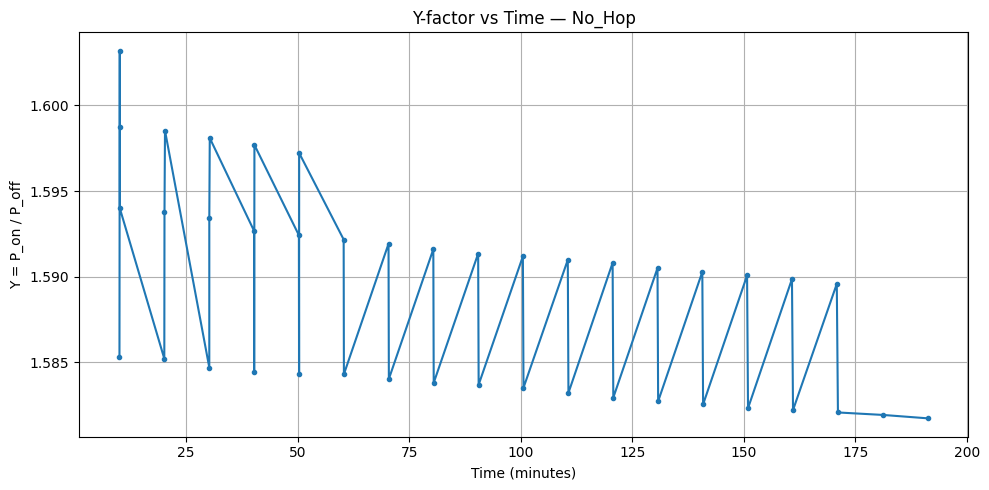


=== Y-Factor Results (No_Hop) ===
Average Y-factor:     1.589
Receiver noise temp:  -290.0 K
Stddev of T_rec:      0.0 K


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ========================
# User parameters
# ========================
method = "No_Hop"   # or "Uniform_Hop", "Gaussian_Hop", etc.
on_path  = "./"
off_path = "./off"

T_hot  = 290.0   # Hot noise source temperature (K), change to your ENR value
T_cold = 290.0   # Ambient cold load (K) if using passive on/off
# If ENR-based:
# ENR_dB = 15
# T_hot = (10**(ENR_dB/10))*290 + 290   # replace above

# Frequency band for power integration (MHz)
fmin = 500
fmax = 1500

def load_spectra(path, method):
    files = sorted(glob.glob(os.path.join(path, f"partial_{method}_*.npz")))
    data = []
    for fn in files:
        try:
            d = np.load(fn)
            data.append((float(d["elapsed_seconds"]), d["F"], d["spec"]))
        except:
            print("Skipping:", fn)
    data.sort(key=lambda x: x[0])
    return data

def avg_power_in_band(F, spec, fmin, fmax):
    idx = np.where((F >= fmin) & (F <= fmax))[0]
    return np.mean(spec[idx])

# ========================
# 1. Load ON and OFF data
# ========================
data_on  = load_spectra(on_path,  method)
data_off = load_spectra(off_path, method)

if len(data_on) == 0 or len(data_off) == 0:
    raise RuntimeError("Missing ON or OFF data for method", method)

time_on  = np.array([d[0] for d in data_on])
time_off = np.array([d[0] for d in data_off])

# ========================
# 2. Match OFF to nearest ON timestamp
# ========================
matched = []
for t_on, F_on, S_on in data_on:
    idx = np.argmin(np.abs(time_off - t_on))
    t_off, F_off, S_off = data_off[idx]

    # integrate band power
    P_on  = avg_power_in_band(F_on,  S_on,  fmin, fmax)
    P_off = avg_power_in_band(F_off, S_off, fmin, fmax)

    matched.append((t_on, P_on, P_off))

matched = np.array(matched, dtype=float)
times = matched[:,0]
P_on  = matched[:,1]
P_off = matched[:,2]

# ========================
# 3. Y-factor computation
# ========================
Y = P_on / P_off

# Noise temperature:
T_rec = (T_hot - Y*T_cold) / (Y - 1)

# ========================
# 4. Plot Y-factor vs time
# ========================
plt.figure(figsize=(10,5))
plt.plot(times/60, Y, '.-', label="Y-factor")
plt.xlabel("Time (minutes)")
plt.ylabel("Y = P_on / P_off")
plt.grid(True)
plt.title(f"Y-factor vs Time — {method}")
plt.tight_layout()
plt.savefig(f"Yfactor_{method}.png", dpi=150)
plt.show()

# ========================
# 5. Print noise temperature results
# ========================
print(f"\n=== Y-Factor Results ({method}) ===")
print("Average Y-factor:     %.3f" % np.mean(Y))
print("Receiver noise temp:  %.1f K" % np.mean(T_rec))
print("Stddev of T_rec:      %.1f K" % np.std(T_rec))


ON time range in 1s window:   602.9272181987762 → 603.9272181987762
OFF time range in 1s window:  607.9158675670624 → 608.9158675670624
Found ON spectra: 1
Found OFF spectra: 1


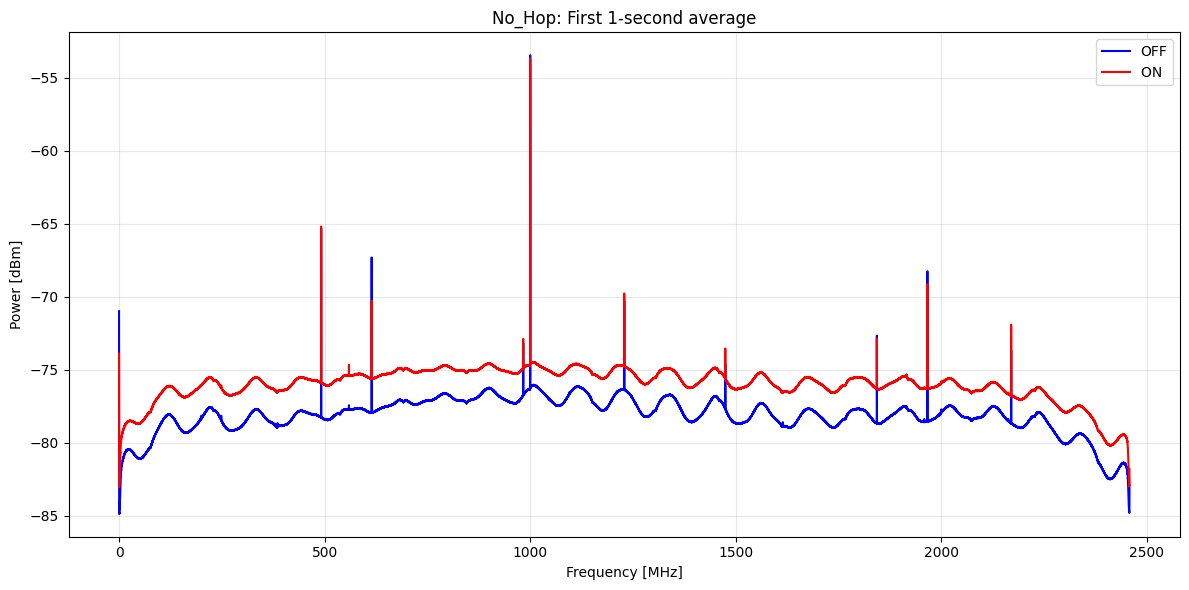

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

method = "No_Hop"
on_path  = "./"
off_path = "./off"

def load_spectra(path, method):
    files = sorted(glob.glob(os.path.join(path, f"partial_{method}_*.npz")))
    data = []
    for fn in files:
        try:
            d = np.load(fn)
            data.append((float(d["elapsed_seconds"]), d["F"], d["spec"]))
        except:
            print("Skipping", fn)
    data.sort(key=lambda x: x[0])
    return data

# Load ON & OFF
data_on  = load_spectra(on_path,  method)
data_off = load_spectra(off_path, method)

if len(data_on) == 0 or len(data_off) == 0:
    raise RuntimeError("Missing ON or OFF data.")

# -----------------------------
# Robust 1-second window
# -----------------------------
t0_on  = data_on[0][0]
t0_off = data_off[0][0]

data_on_1  = [d for d in data_on  if t0_on  <= d[0] <= t0_on  + 1.0]
data_off_1 = [d for d in data_off if t0_off <= d[0] <= t0_off + 1.0]

print("ON time range in 1s window:  ", t0_on,  "→", t0_on+1.0)
print("OFF time range in 1s window: ", t0_off, "→", t0_off+1.0)
print("Found ON spectra:", len(data_on_1))
print("Found OFF spectra:", len(data_off_1))

if len(data_on_1) == 0 or len(data_off_1) == 0:
    raise RuntimeError("No spectra fell inside the first 1-second window.")

# -----------------------------
# Stack and average
# -----------------------------
F = data_on_1[0][1]

S_on_avg  = np.mean([d[2] for d in data_on_1], axis=0)
S_off_avg = np.mean([d[2] for d in data_off_1], axis=0)

def to_dBm(spec, R=50):
    return 10*np.log10(np.maximum(spec/(2*R*1e-3), 1e-20))

S_on_dBm  = to_dBm(S_on_avg)
S_off_dBm = to_dBm(S_off_avg)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(F, S_off_dBm, label="OFF", color="blue")
plt.plot(F, S_on_dBm,  label="ON ", color="red")
plt.title(f"{method}: First 1-second average")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power [dBm]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"ON_OFF_1sec_{method}.png", dpi=150)
plt.show()



--- Time windows ---
ON window:   602.9272181987762 → 1502.9272181987762
OFF window:  607.9158675670624 → 1507.9158675670624

Found ON spectra:  7
Found OFF spectra: 1


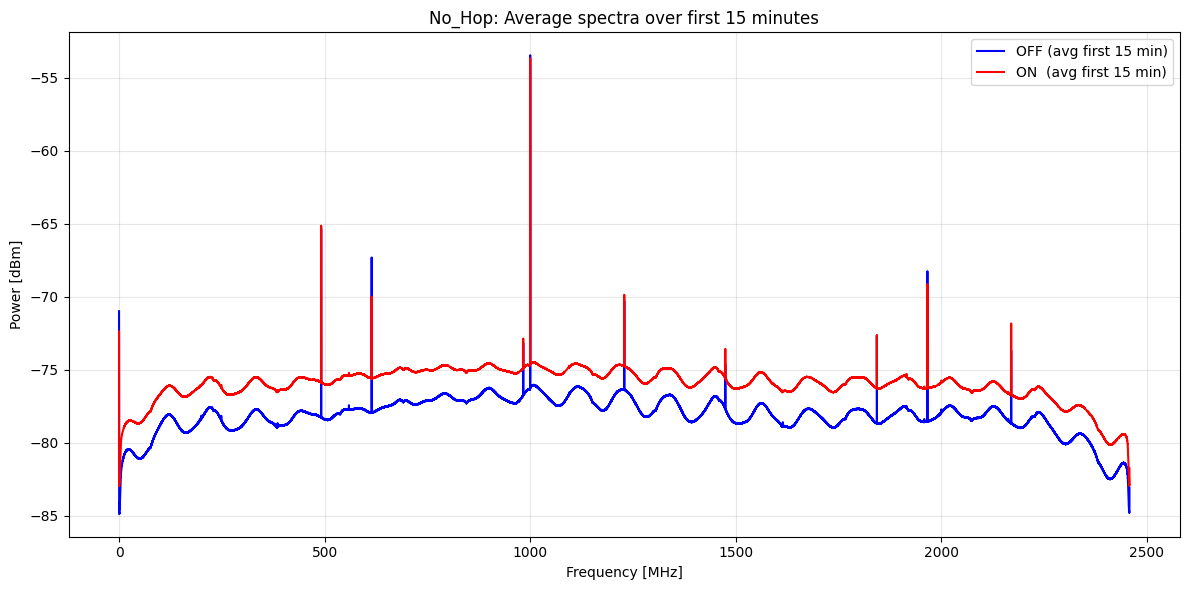

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ========= User settings =========
method = "No_Hop"         # or whichever method you want
on_path  = "./"
off_path = "./off"

T_limit = 15 * 60         # 15 minutes = 900 seconds

def load_spectra(path, method):
    files = sorted(glob.glob(os.path.join(path, f"partial_{method}_*.npz")))
    data = []
    for fn in files:
        try:
            d = np.load(fn)
            data.append((float(d["elapsed_seconds"]), d["F"], d["spec"]))
        except:
            print("Skipping", fn)
    data.sort(key=lambda x: x[0])
    return data

# ============================
# Load ON and OFF
# ============================
data_on  = load_spectra(on_path,  method)
data_off = load_spectra(off_path, method)

if len(data_on) == 0:
    raise RuntimeError("No ON data found.")
if len(data_off) == 0:
    raise RuntimeError("No OFF data found.")

# ============================
# Define robust 15-minute windows
# ============================
t0_on  = data_on[0][0]
t0_off = data_off[0][0]

on_window_start  = t0_on
on_window_end    = t0_on  + T_limit

off_window_start = t0_off
off_window_end   = t0_off + T_limit

data_on_15  = [d for d in data_on  if on_window_start  <= d[0] <= on_window_end]
data_off_15 = [d for d in data_off if off_window_start <= d[0] <= off_window_end]

print("\n--- Time windows ---")
print("ON window:  ", on_window_start,  "→", on_window_end)
print("OFF window: ", off_window_start, "→", off_window_end)

print("\nFound ON spectra: ", len(data_on_15))
print("Found OFF spectra:", len(data_off_15))

if len(data_on_15) == 0 or len(data_off_15) == 0:
    raise RuntimeError("Not enough spectra in 15-minute window.")

# ============================
# Stack and average
# ============================
F = data_on_15[0][1]

S_on_avg  = np.mean([d[2] for d in data_on_15], axis=0)
S_off_avg = np.mean([d[2] for d in data_off_15], axis=0)

# ============================
# Convert to dBm
# ============================
def to_dBm(spec, R=50):
    return 10*np.log10(np.maximum(spec/(2*R*1e-3), 1e-20))

S_on_dBm  = to_dBm(S_on_avg)
S_off_dBm = to_dBm(S_off_avg)

# ============================
# Plot
# ============================
plt.figure(figsize=(12,6))
plt.plot(F, S_off_dBm, label="OFF (avg first 15 min)", color="blue")
plt.plot(F, S_on_dBm,  label="ON  (avg first 15 min)",  color="red")
plt.title(f"{method}: Average spectra over first 15 minutes")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power [dBm]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"ON_OFF_15min_{method}.png", dpi=150)
plt.show()



Found ON spectra in first 1 s : 1
Found OFF spectra in first 1 s: 1


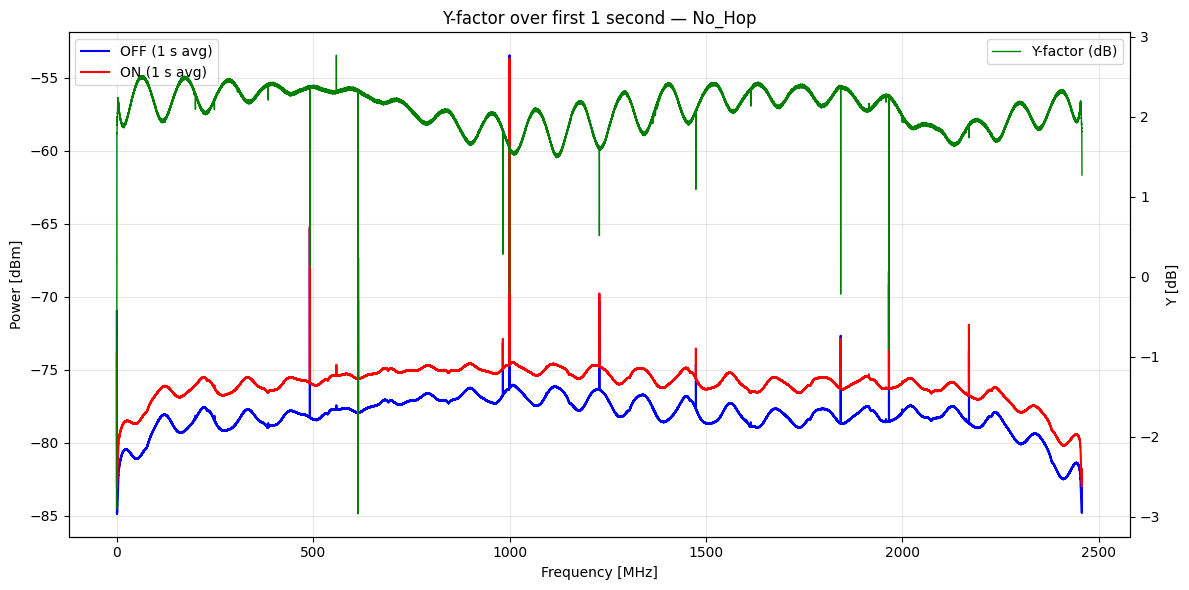

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

method = "No_Hop"     # or Uniform_Hop / Gaussian_Hop / ...
on_path = "./"
off_path = "./off"

T_limit = 1.0   # 1 second window


def load_spectra(path, method):
    files = sorted(glob.glob(os.path.join(path, f"partial_{method}_*.npz")))
    data = []
    for fn in files:
        try:
            d = np.load(fn)
            data.append((float(d["elapsed_seconds"]), d["F"], d["spec"]))
        except:
            print("Skipping", fn)
    data.sort(key=lambda x: x[0])
    return data


# ============================
# Load ON / OFF
# ============================
data_on  = load_spectra(on_path,  method)
data_off = load_spectra(off_path, method)

if len(data_on) == 0:
    raise RuntimeError("No ON data found.")
if len(data_off) == 0:
    raise RuntimeError("No OFF data found.")


# ============================
# Select first 1-second window
# ============================
t0_on  = data_on[0][0]
t0_off = data_off[0][0]

on_window_start  = t0_on
on_window_end    = t0_on  + T_limit

off_window_start = t0_off
off_window_end   = t0_off + T_limit

data_on_1  = [d for d in data_on  if on_window_start  <= d[0] <= on_window_end]
data_off_1 = [d for d in data_off if off_window_start <= d[0] <= off_window_end]

print("\nFound ON spectra in first 1 s :", len(data_on_1))
print("Found OFF spectra in first 1 s:", len(data_off_1))

if len(data_on_1) == 0 or len(data_off_1) == 0:
    raise RuntimeError("Not enough spectra in first 1 second.")


# ============================
# Average spectra
# ============================
F = data_on_1[0][1]

S_on_avg  = np.mean([d[2] for d in data_on_1], axis=0)
S_off_avg = np.mean([d[2] for d in data_off_1], axis=0)


# ============================
# Convert to dBm for plotting
# ============================
def to_dBm(spec, R=50):
    return 10 * np.log10(np.maximum(spec/(2*R*1e-3), 1e-20))

S_on_dBm  = to_dBm(S_on_avg)
S_off_dBm = to_dBm(S_off_avg)


# ============================
# Y-factor calculation
# ============================
Y_linear = S_on_avg / S_off_avg
Y_dB = 10 * np.log10(np.maximum(Y_linear, 1e-20))


# ============================
# Plot
# ============================
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(F, S_off_dBm, label="OFF (1 s avg)", color="blue")
ax1.plot(F, S_on_dBm,  label="ON (1 s avg)",  color="red")

ax1.set_xlabel("Frequency [MHz]")
ax1.set_ylabel("Power [dBm]")
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

# Y-factor axis
ax2 = ax1.twinx()
ax2.plot(F, Y_dB, color="green", linewidth=1, label="Y-factor (dB)")
ax2.set_ylabel("Y [dB]")
ax2.legend(loc="upper right")

plt.title(f"Y-factor over first 1 second — {method}")
plt.tight_layout()
plt.savefig(f"Yfactor_1s_{method}.png", dpi=150)
plt.show()


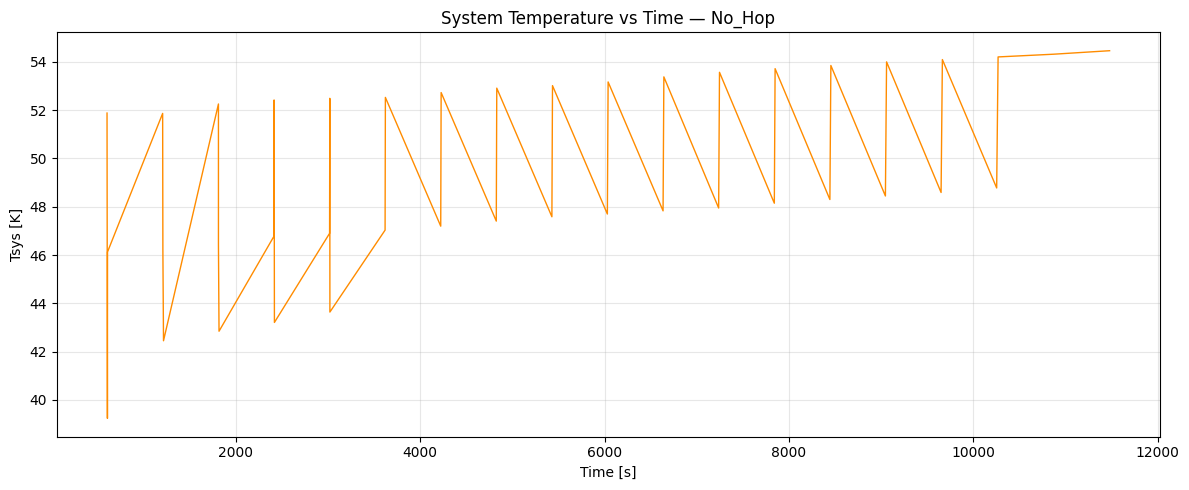

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

method = "No_Hop"
on_path = "./"
off_path = "./off"

# Calibration temperatures [K]
T_hot  = 500  # example, adjust to your noise source
T_cold = 290  # ambient

def load_spectra(path, method):
    files = sorted(glob.glob(os.path.join(path, f"partial_{method}_*.npz")))
    data = []
    for fn in files:
        try:
            d = np.load(fn)
            data.append((float(d["elapsed_seconds"]), d["spec"]))
        except:
            print("Skipping", fn)
    data.sort(key=lambda x: x[0])
    return data

# ============================
# Load ON / OFF
# ============================
data_on  = load_spectra(on_path,  method)
data_off = load_spectra(off_path, method)

if len(data_on) == 0 or len(data_off) == 0:
    raise RuntimeError("No data found.")


# ============================
# Interpolate OFF to ON times
# ============================
times_on  = np.array([d[0] for d in data_on])
specs_on  = np.array([d[1] for d in data_on])

times_off = np.array([d[0] for d in data_off])
specs_off = np.array([d[1] for d in data_off])

# Interpolate OFF spectra to ON times
from scipy.interpolate import interp1d

spec_off_interp_func = interp1d(times_off, specs_off, axis=0, kind='nearest', fill_value='extrapolate')
specs_off_interp = spec_off_interp_func(times_on)


# ============================
# Compute Y-factor and Tsys per spectrum
# ============================
Y_t = specs_on / specs_off_interp
Tsys_t = (T_hot - Y_t * T_cold) / (Y_t - 1)

# Average over frequency to get single Tsys vs time
Tsys_avg = np.mean(Tsys_t, axis=1)

# ============================
# Plot
# ============================
plt.figure(figsize=(12,5))
plt.plot(times_on, Tsys_avg, color='darkorange', lw=1)
plt.xlabel("Time [s]")
plt.ylabel("Tsys [K]")
plt.title(f"System Temperature vs Time — {method}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
!pip install scipy

   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   -------------------- ------------------- 19.4/38.5 MB 105.3 MB/s eta 0:00:01
   ---------------------------------------  38.3/38.5 MB 111.6 MB/s eta 0:00:01
   ---------------------------------------- 38.5/38.5 MB 94.5 MB/s eta 0:00:00


In [16]:
# Find index of spectrum closest to 1 second
idx_1s = np.argmin(np.abs(times_on - 1.0))

# Extract Tsys at that time
Tsys_1s = Tsys_avg[idx_1s]

print(f"Tsys at ~1 second: {Tsys_1s:.2f} K")


Tsys at ~1 second: 51.88 K


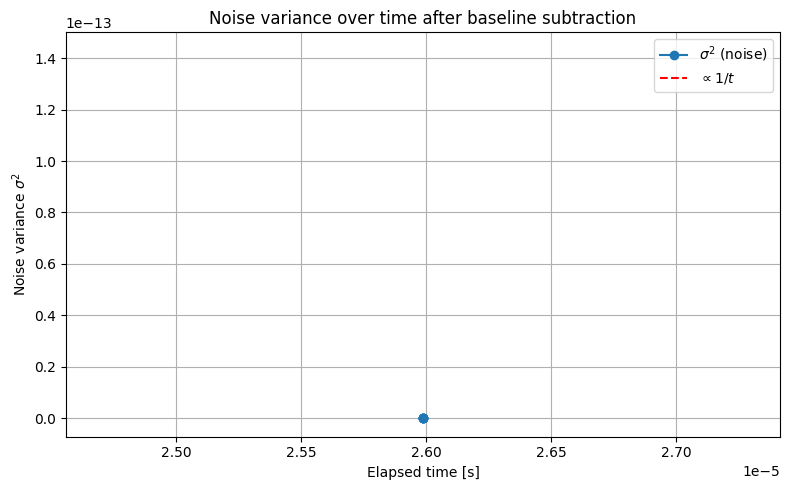

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# =================================
# Parameters
# =================================
signal_folder = "signal"  # folder with .npz spectra
window_length = 101       # Savitzky-Golay window
polyorder = 3
peak_sigma_cut = 5        # clip peaks above median + n*std

# =================================
# Load files
# =================================
files = sorted([f for f in os.listdir(signal_folder) if f.endswith(".npz")])
if not files:
    raise RuntimeError(f"No .npz files found in {signal_folder}")

all_times = []
all_sigma2 = []

for fname in files:
    data = np.load(os.path.join(signal_folder, fname))
    
    spec = data['spec']       # linear units
    times = data['times']     # elapsed seconds
    if spec.ndim == 2:        # sometimes averaged arrays
        spec = spec.mean(axis=0)

    sigma2_list = []
    for s in spec if spec.ndim > 1 else [spec]:
        # fit baseline with Savitzky-Golay
        baseline = savgol_filter(s, window_length=window_length, polyorder=polyorder)
        residual = s - baseline

        # exclude peaks
        median = np.median(residual)
        std = np.std(residual)
        mask = residual < median + peak_sigma_cut * std
        noise_var = np.var(residual[mask])
        sigma2_list.append(noise_var)

    # average variance across spectra if multiple
    all_sigma2.append(np.mean(sigma2_list))
    all_times.append(times if np.isscalar(times) else times[0])

# =================================
# Plot σ² over time
# =================================
plt.figure(figsize=(8,5))
plt.plot(all_times, all_sigma2, 'o-', label=r'$\sigma^2$ (noise)')
plt.xlabel("Elapsed time [s]")
plt.ylabel(r"Noise variance $\sigma^2$")
plt.title("Noise variance over time after baseline subtraction")

# overlay 1/t dotted line
t_ref = np.array(all_times)
sigma0 = all_sigma2[0]
plt.plot(t_ref, sigma0/t_ref, 'r--', label=r'$\propto 1/t$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


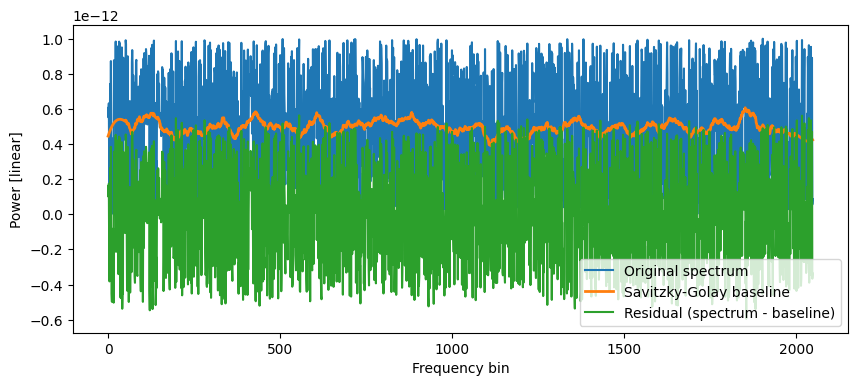

Variance sigma^2: 8.384174937129647e-26


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Example spectrum (linear scale)
spec = np.random.rand(2048) * 1e-12  # replace with your spectrum

# Fit baseline with Savitzky-Golay filter
baseline = savgol_filter(spec, window_length=101, polyorder=3)

# Subtract baseline to get residual
residual = spec - baseline

# Plot spectrum, baseline, residual
plt.figure(figsize=(10,4))
plt.plot(spec, label="Original spectrum")
plt.plot(baseline, label="Savitzky-Golay baseline", linewidth=2)
plt.plot(residual, label="Residual (spectrum - baseline)")
plt.xlabel("Frequency bin")
plt.ylabel("Power [linear]")
plt.legend()
plt.show()

# Exclude peaks above median + 5σ
median = np.median(residual)
std = np.std(residual)
mask = residual < median + 5*std

# Variance of noise on linear scale
sigma2 = np.var(residual[mask])
print("Variance sigma^2:", sigma2)


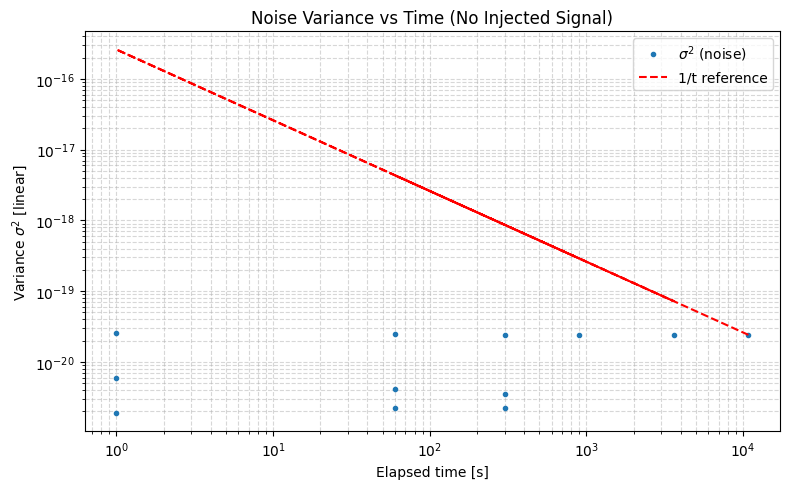

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import glob
import os

# -------------------------
# Configuration
# -------------------------
data_folder = "./"   # base directory with 'on' spectra .npz files
file_pattern = os.path.join(data_folder, "final*_No_Hop_*.npz")  # adjust as needed
window_length = 101   # for Savitzky-Golay filter (should be odd)
polyorder = 3

# -------------------------
# Load all files
# -------------------------
files = sorted(glob.glob(file_pattern))
sigma2_list = []
time_list = []

for f in files:
    npz = np.load(f)
    spec = npz['spec']  # shape could be (N_spectra, N_points) or (N_points,)
    elapsed = npz.get('duration', npz.get('elapsed_seconds', 0))

    # Ensure 2D for consistent processing
    if spec.ndim == 1:
        spec = spec[np.newaxis, :]

    # Loop over individual spectra in this file
    for i in range(spec.shape[0]):
        s = spec[i]

        # Fit baseline
        baseline = savgol_filter(s, window_length=window_length, polyorder=polyorder)

        # Residual = spectrum - baseline
        residual = s - baseline

        # Mask peaks above median + 5 sigma
        med = np.median(residual)
        std = np.std(residual)
        mask = residual < med + 5*std

        # Variance on linear scale excluding peaks
        sigma2 = np.var(residual[mask])

        sigma2_list.append(sigma2)
        # Use cumulative time if elapsed is per file, or just 1 per spectrum
        time_list.append(elapsed)

# Convert to numpy arrays
sigma2_arr = np.array(sigma2_list)
time_arr = np.array(time_list)

# -------------------------
# Plot sigma^2 vs time
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(time_arr, sigma2_arr, '.', label=r'$\sigma^2$ (noise)')
plt.xlabel("Elapsed time [s]")
plt.ylabel(r"Variance $\sigma^2$ [linear]")
plt.title("Noise Variance vs Time (No Injected Signal)")

# Overlay 1/t trend line
t0 = time_arr[0] if time_arr[0] > 0 else 1.0
sigma0 = sigma2_arr[0]
plt.plot(time_arr, sigma0 * t0 / np.maximum(time_arr, 1e-12), 'r--', label=r'1/t reference')

plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


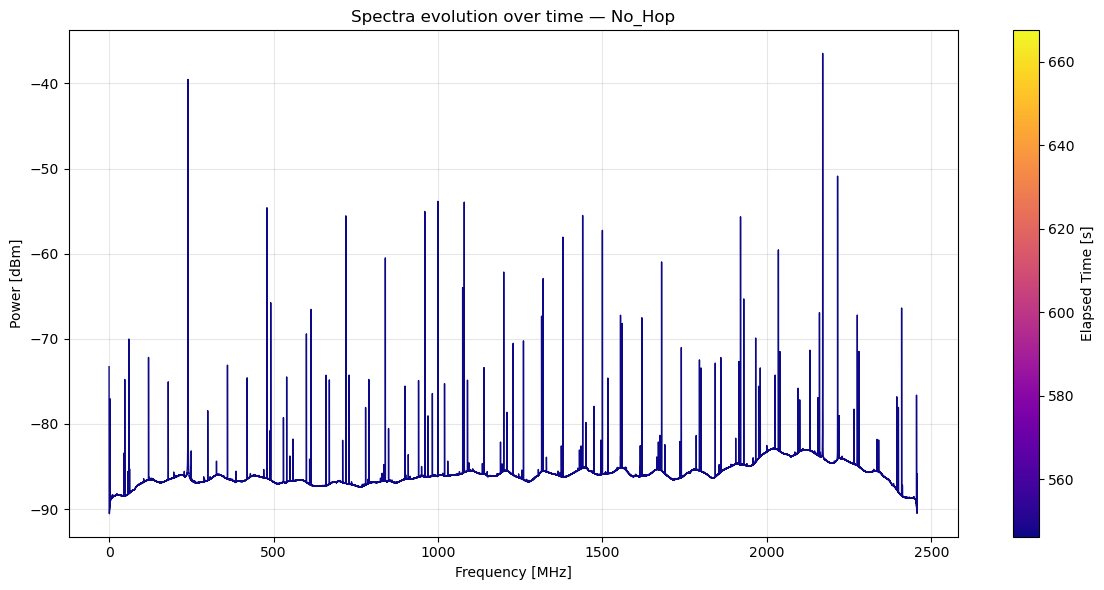

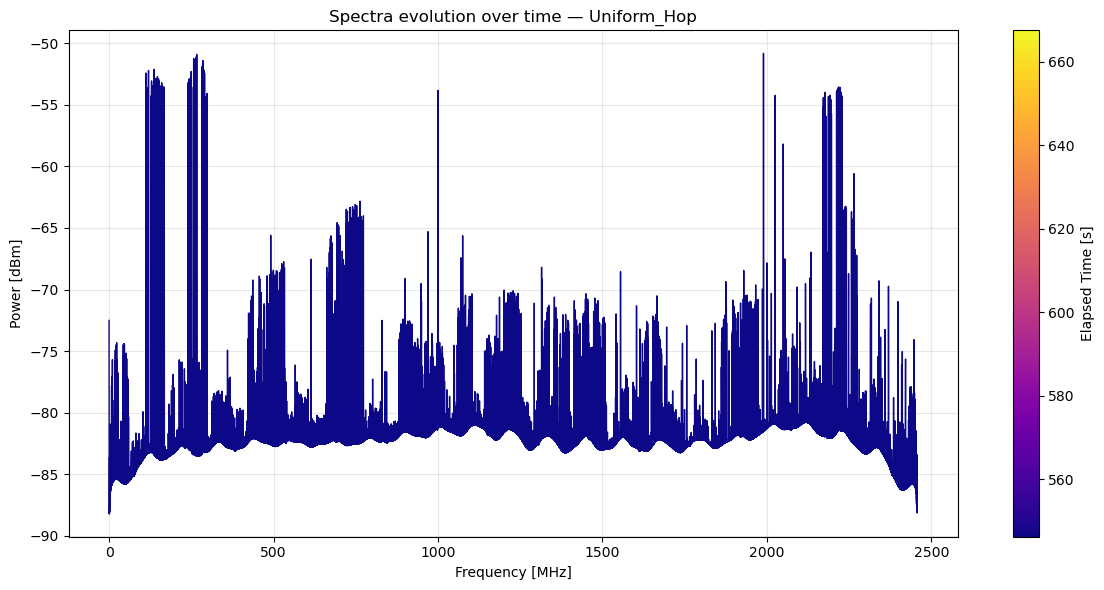

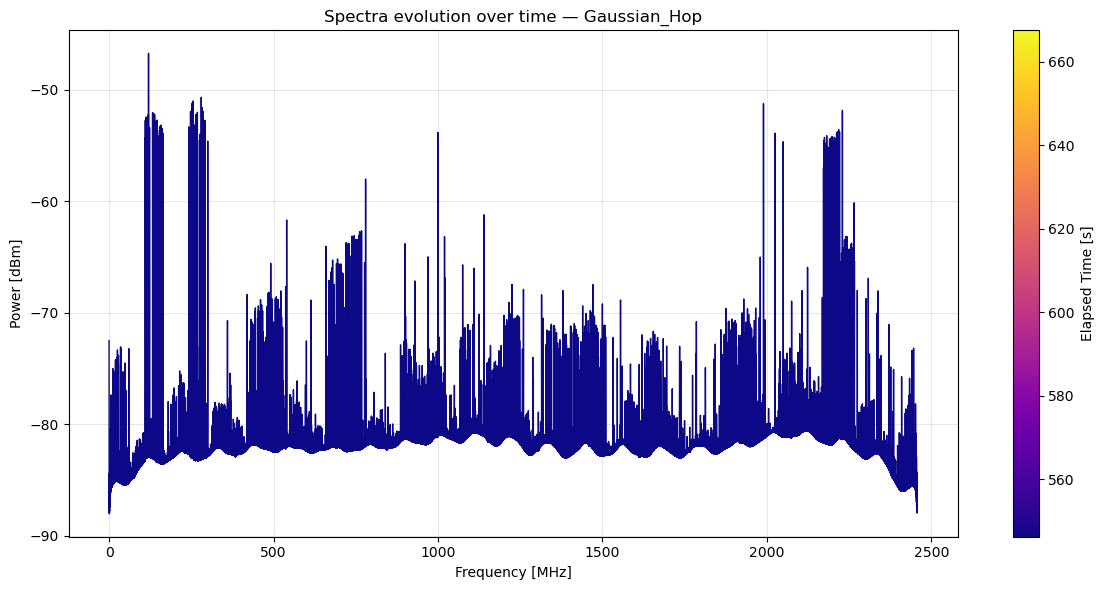

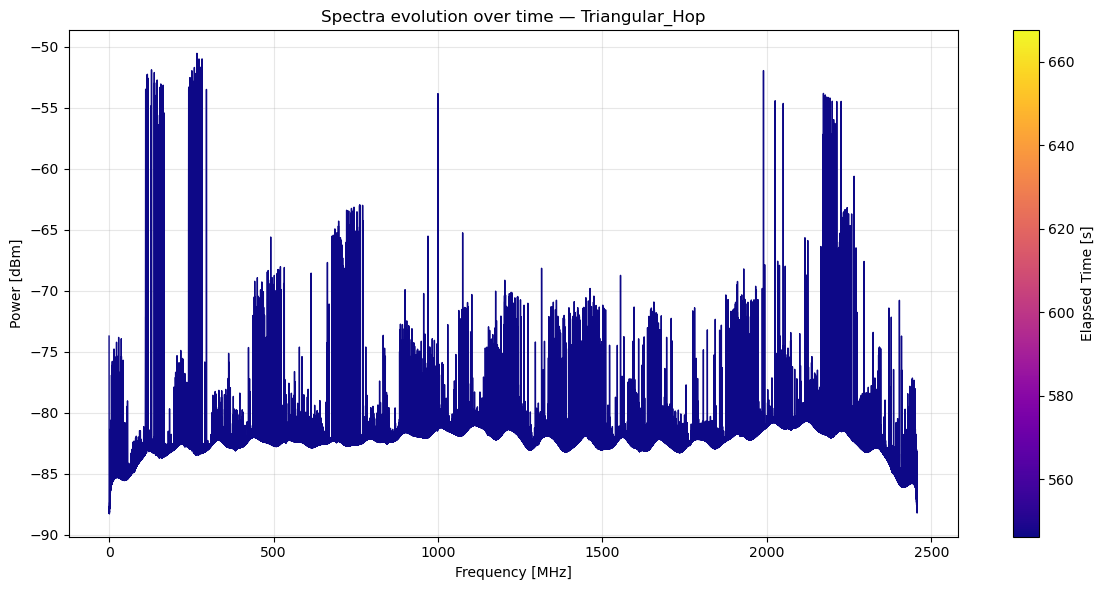

No data for Cosine2_Hop


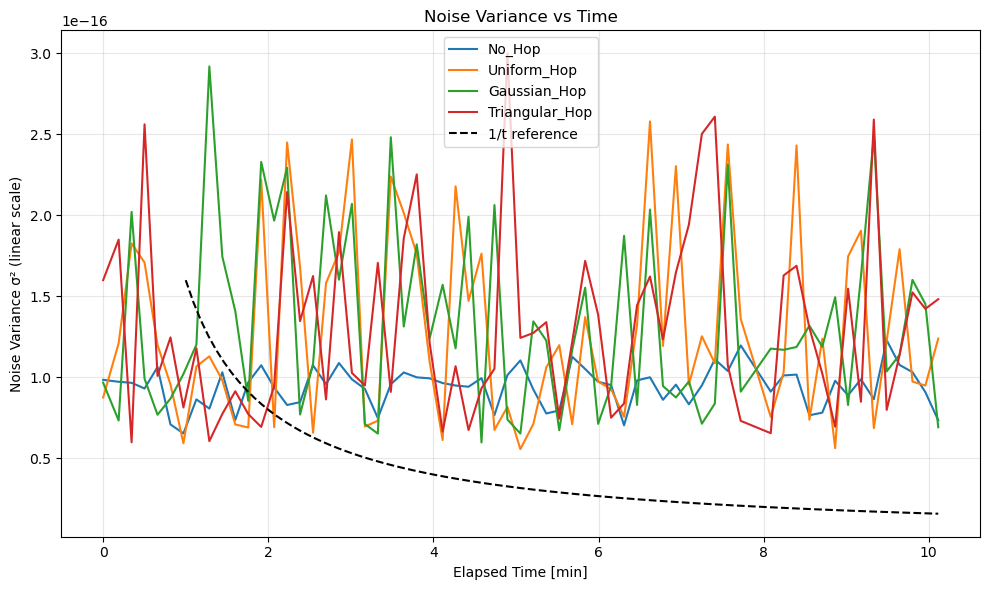

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# -------------------------------
# Parameters
# -------------------------------
path = "./signal"  # folder where your incremental .npz files are
method_names = ["No_Hop", "Uniform_Hop", "Gaussian_Hop", "Triangular_Hop", "Cosine2_Hop"]
R = 50  # load resistance

def to_dBm(spec, R=50):
    return 10*np.log10(np.maximum(spec / (2*R*1e-3), 1e-20))

def load_incremental_files(method):
    files = sorted(glob.glob(os.path.join(path, f"partial_{method}_*.npz")))
    data = []
    for fn in files:
        try:
            d = np.load(fn)
            data.append({
                'elapsed': float(d['elapsed_seconds']),
                'F': d['F'],
                'avg_spec': d['spec'],
                'noise_var': d['noise_variances'],
                'times': d['times']
            })
        except Exception as e:
            print("Skipping file", fn, e)
    return data

# -------------------------------
# Plot spectra overlay over time
# -------------------------------
for method in method_names:
    data = load_incremental_files(method)
    if not data:
        print(f"No data for {method}")
        continue

    cmap = plt.cm.plasma
    times = np.array([d['elapsed'] for d in data])
    t_norm = (times - times.min()) / (times.max() - times.min() + 1e-12)

    fig, ax = plt.subplots(figsize=(12,6))
    ax.set_title(f"Spectra evolution over time — {method}")
    
    for d, c in zip(data, cmap(t_norm)):
        ax.plot(d['F'], to_dBm(d['avg_spec']), color=c, lw=1)
    
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Power [dBm]")

    ax.grid(True, alpha=0.3)

    # ScalarMappable for colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=times.min(), vmax=times.max()))
    sm.set_array([])  # needed, but can be empty
    cbar = fig.colorbar(sm, ax=ax)  # explicitly attach to ax
    cbar.set_label("Elapsed Time [s]")

    plt.tight_layout()
    plt.savefig(os.path.join(path,f"spectra_overlay_{method}.png"), dpi=150)
    plt.show()

# -------------------------------
# Plot noise variance σ² vs time
# -------------------------------
plt.figure(figsize=(10,6))
any_data = False

for method in method_names:
    data = load_incremental_files(method)
    if not data:
        continue
    any_data = True
    all_times = []
    all_vars = []
    for d in data:
        all_times.extend(d['times'])
        all_vars.extend(d['noise_var'])
    all_times = np.array(all_times)
    all_vars = np.array(all_vars)
    plt.plot(all_times/60, all_vars, label=method, lw=1.5)

if any_data:
    # 1/t reference line
    t_ref = np.linspace(1, max(all_times)/60, 100)  # minutes
    sigma0 = all_vars[0] if len(all_vars)>0 else 1
    plt.plot(t_ref, sigma0/t_ref, 'k--', label="1/t reference")

plt.xlabel("Elapsed Time [min]")
plt.ylabel("Noise Variance σ² (linear scale)")
plt.title("Noise Variance vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(path,"noise_variance_vs_time.png"), dpi=150)
plt.show()

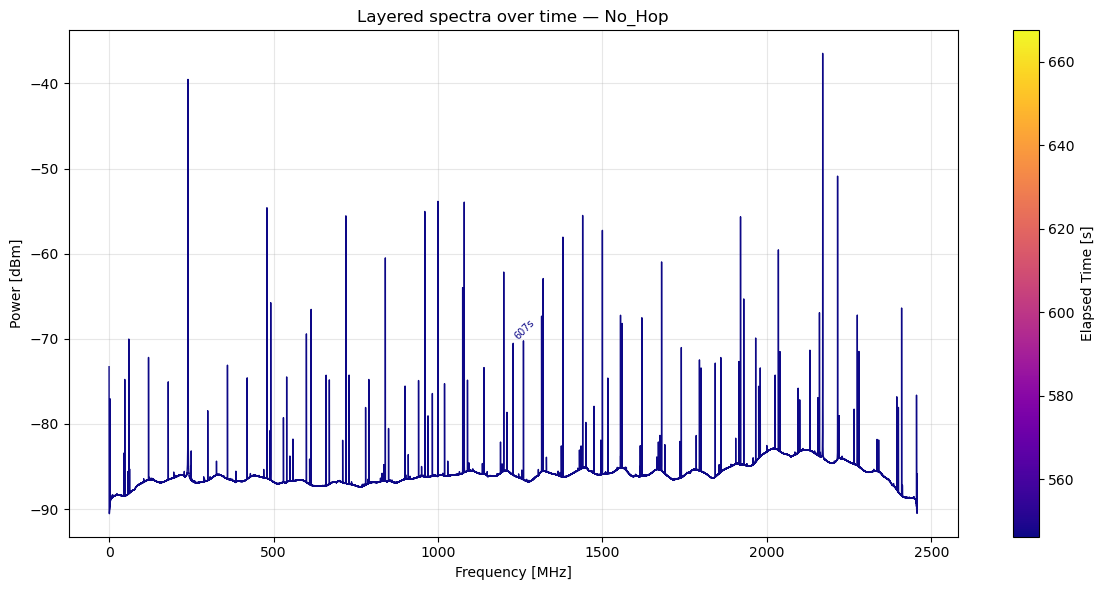

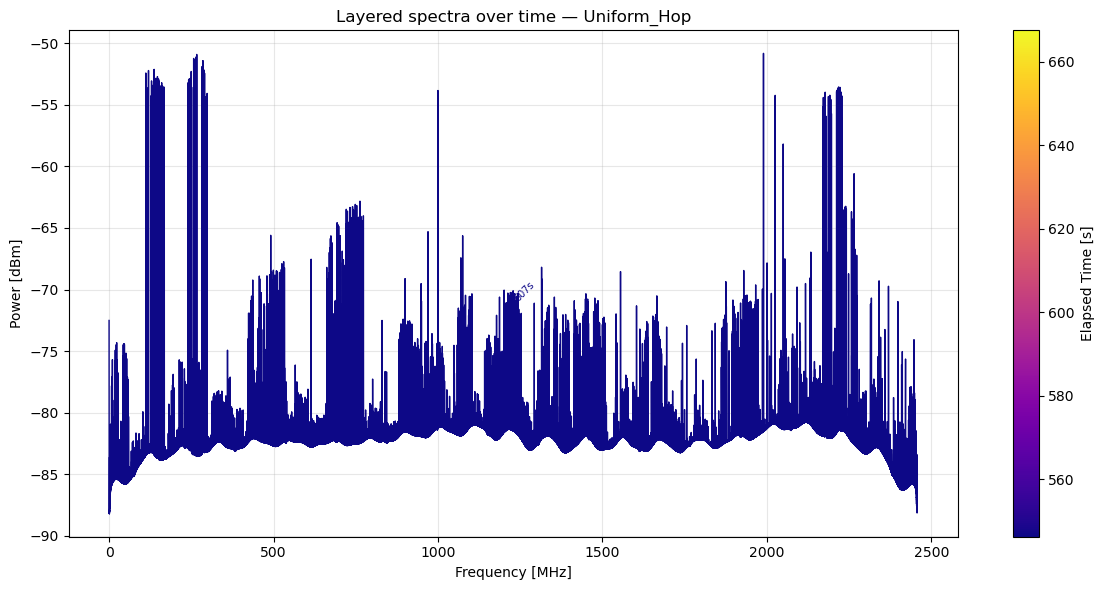

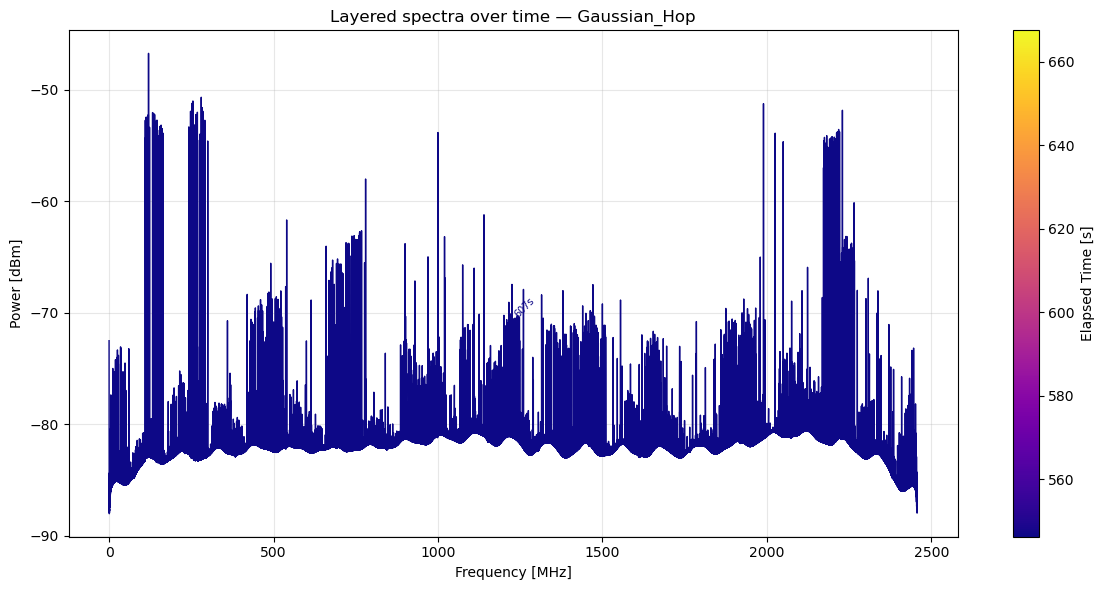

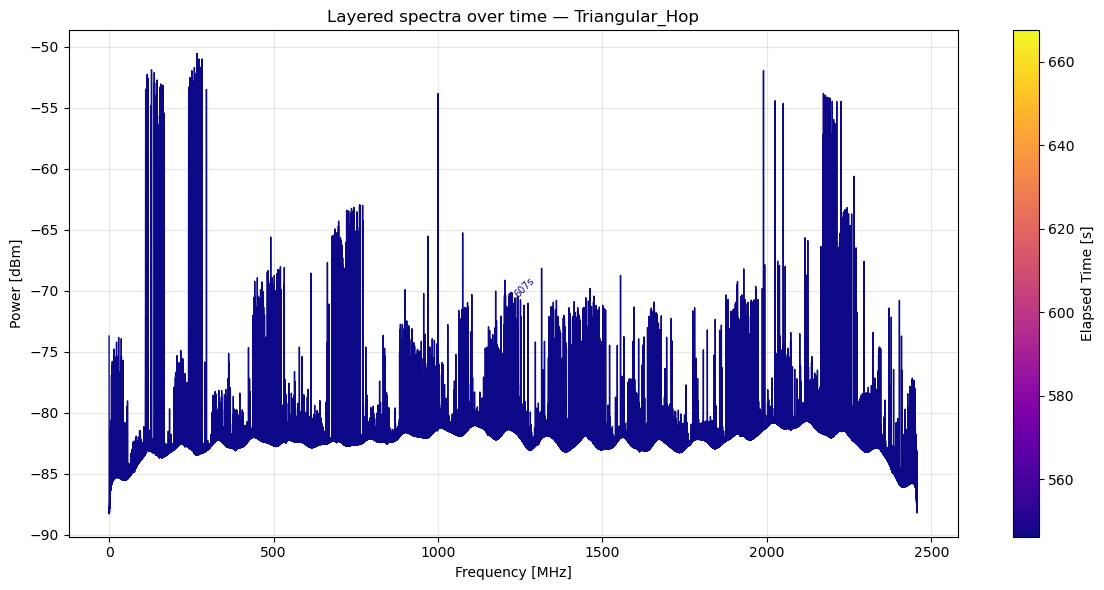

No data for Cosine2_Hop


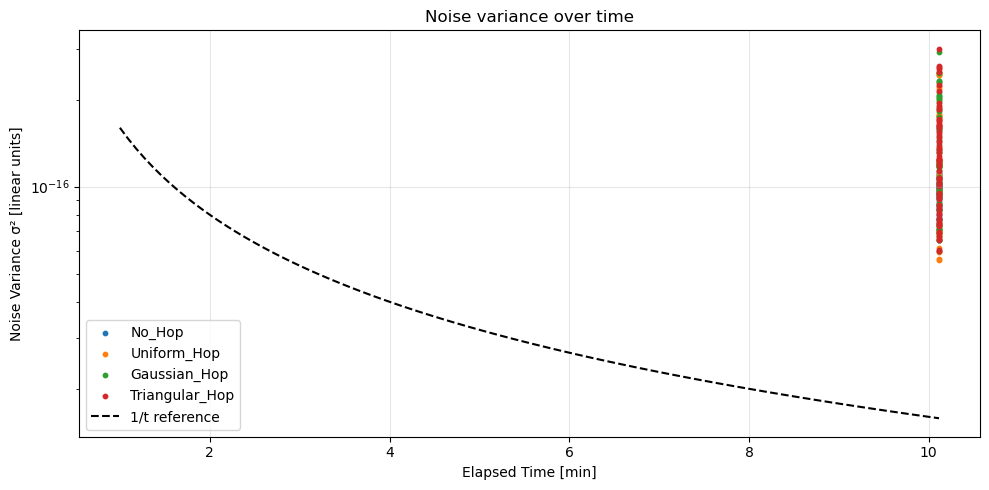

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

path = "./signal"
method_names = ["No_Hop", "Uniform_Hop", "Gaussian_Hop", "Triangular_Hop", "Cosine2_Hop"]

def load_incremental_files(method):
    """Load partial or final spectra with noise variance."""
    files = sorted(glob.glob(os.path.join(path, f"*{method}*.npz")))
    data = []
    for fn in files:
        try:
            d = np.load(fn)
            data.append({
                'elapsed': float(d['elapsed_seconds']),
                'F': d['F'],
                'avg_spec': d['spec'],
                'noise_var': d['noise_variances'],
            })
        except:
            print("Skipping", fn)
    data.sort(key=lambda x: x['elapsed'])
    return data

def to_dBm(spec, R=50):
    return 10*np.log10(np.maximum(spec / (2*R*1e-3), 1e-20))

# -------------------------------------
# Plot layered spectra with averaging time
# -------------------------------------
for method in method_names:
    data = load_incremental_files(method)
    if not data:
        print(f"No data for {method}")
        continue

    cmap = plt.cm.plasma
    times = np.array([d['elapsed'] for d in data])
    t_norm = (times - times.min()) / (times.max() - times.min() + 1e-12)

    fig, ax = plt.subplots(figsize=(12,6))
    ax.set_title(f"Layered spectra over time — {method}")

    for d, c in zip(data, cmap(t_norm)):
        ax.plot(d['F'], to_dBm(d['avg_spec']), color=c, lw=1)
        # Annotate with averaging time
        mid_idx = len(d['F']) // 2
        ax.text(d['F'][mid_idx], to_dBm(d['avg_spec'])[mid_idx]+0.5, 
                f"{d['elapsed']:.0f}s", fontsize=7, color=c, rotation=45)

    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Power [dBm]")
    ax.grid(True, alpha=0.3)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=times.min(), vmax=times.max()))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Elapsed Time [s]")

    plt.tight_layout()
    plt.show()

# -------------------------------------
# Plot sigma squared (noise variance) vs time as points
# -------------------------------------
fig, ax = plt.subplots(figsize=(10,5))
for method in method_names:
    data = load_incremental_files(method)
    if not data:
        continue
    all_times = []
    all_vars = []
    for d in data:
        all_times.extend([d['elapsed']] * len(d['noise_var']))
        all_vars.extend(d['noise_var'])
    all_times = np.array(all_times)
    all_vars = np.array(all_vars)
    ax.scatter(all_times/60, all_vars, label=method, s=10)  # s=10 for small points

# Optional: 1/t reference line (dotted)
t_ref = np.linspace(1, max(all_times)/60, 100)
sigma0 = all_vars[0] if len(all_vars) > 0 else 1
ax.plot(t_ref, sigma0/t_ref, 'k--', label='1/t reference')

ax.set_xlabel("Elapsed Time [min]")
ax.set_ylabel("Noise Variance σ² [linear units]")
ax.set_title("Noise variance over time")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

/var/folders/y2/qh0xmfp57pg1gkfyt952g7ww0000gp/T/ipykernel_62019/1450102241.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


Saved: gaussian_hop_random_5MHz_time_evolution_grid.png


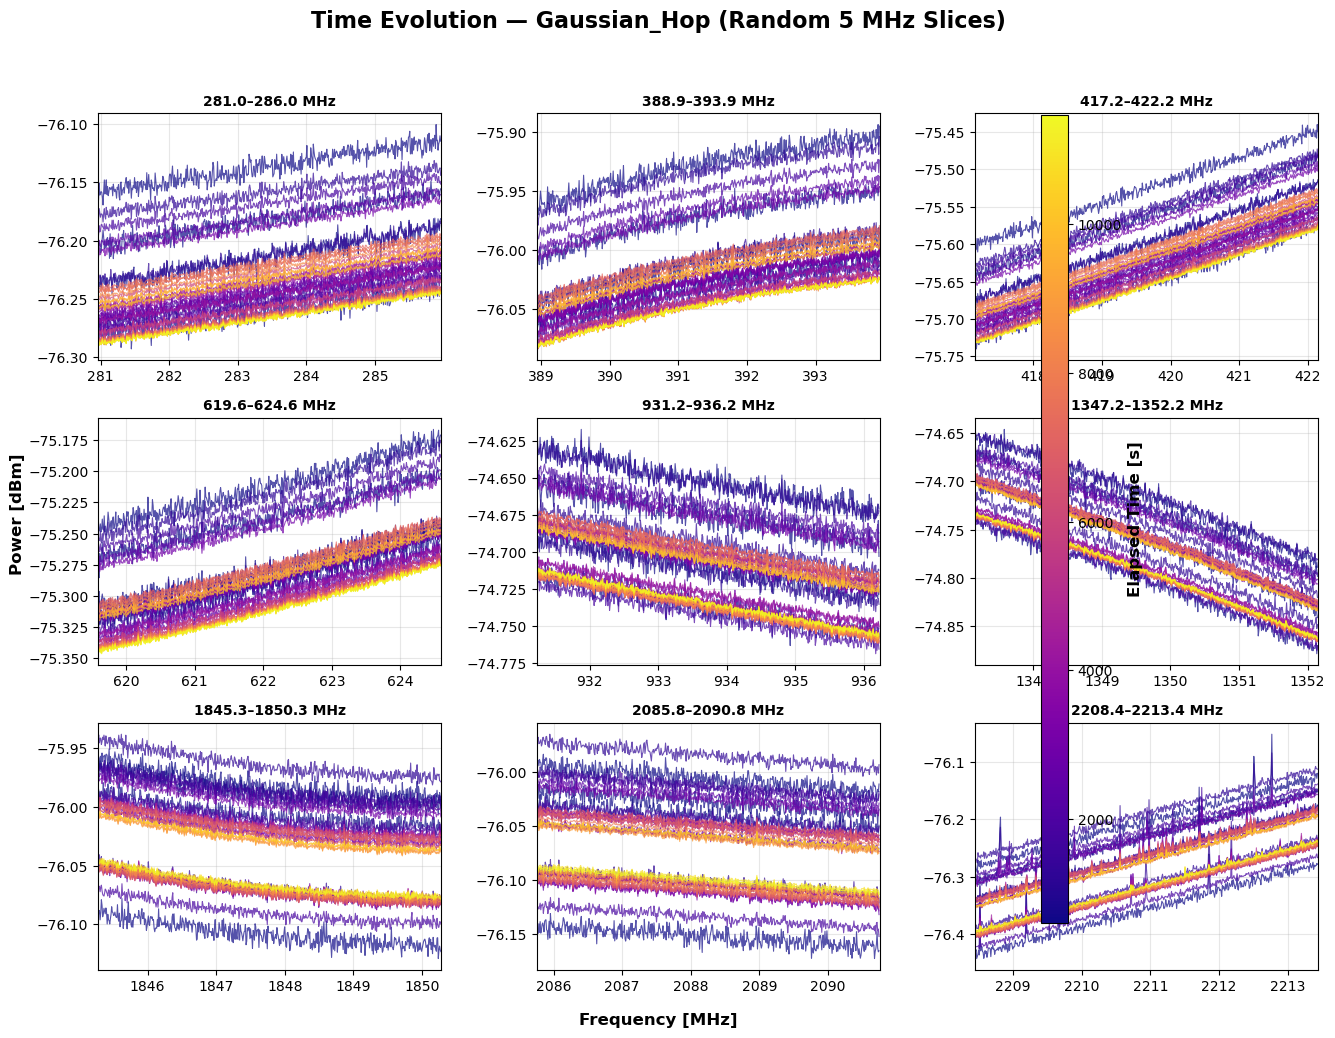

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import random
import glob
import os

path = "./"
method = "Gaussian_Hop"
MHz_window = 5.0
n_windows = 9       # number of random 5 MHz slices
max_lines = 40      # cap number of spectra per subplot

def load_spectra(method):
    files = sorted(glob.glob(os.path.join(path, f"partial_{method}_*.npz")))
    data = []
    for fn in files:
        try:
            d = np.load(fn)
            data.append((float(d["elapsed_seconds"]), d["F"], d["spec"]))
        except:
            print("Skipping:", fn)
    data.sort(key=lambda x: x[0])
    return data

def to_dBm(spec, R=50):
    return 10*np.log10(np.maximum(spec / (2*R*1e-3), 1e-20))

# -------------------------------
# Load data
# -------------------------------
data = load_spectra(method)
if len(data) == 0:
    raise ValueError("No data loaded for Gaussian_Hop")

all_elapsed_times = np.array([d[0] for d in data])
F_full = data[0][1]   # frequency axis reference

# Valid frequency range
f_min = F_full.min()
f_max = F_full.max() - MHz_window

# Random 5 MHz start frequencies
random_starts = sorted(random.sample(list(np.linspace(f_min, f_max, 2000)), n_windows))

# Grid layout
ncols = int(np.ceil(np.sqrt(n_windows)))
nrows = int(np.ceil(n_windows / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows), sharey=False)
axes = axes.flatten()

# Time colormap
norm = Normalize(vmin=all_elapsed_times.min(), vmax=all_elapsed_times.max())
cmap = plt.cm.plasma

# Subsample times to avoid overcrowding
if len(all_elapsed_times) > max_lines:
    step = len(all_elapsed_times) // max_lines
    plot_data = data[::step]
else:
    plot_data = data

# -------------------------------
# Plot each random window
# -------------------------------
for ax, f0 in zip(axes, random_starts):
    f1 = f0 + MHz_window
    y_values = []

    for t, F, spec in plot_data:
        mask = (F >= f0) & (F <= f1)
        y = to_dBm(spec[mask])
        y_values.extend(y)
        ax.plot(F[mask], y, color=cmap(norm(t)), linewidth=0.8, alpha=0.7)

    # Dynamic y-axis zoom
    if y_values:
        ymin, ymax = min(y_values), max(y_values)
        margin = 0.05*(ymax - ymin)
        ax.set_ylim(ymin - margin, ymax + margin)

    ax.set_xlim(f0, f1)
    ax.set_title(f"{f0:.1f}–{f1:.1f} MHz", fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Turn off unused axes
for ax in axes[len(random_starts):]:
    ax.axis('off')

# Global labels
fig.suptitle("Time Evolution — Gaussian_Hop (Random 5 MHz Slices)", fontsize=16, fontweight='bold')
fig.supxlabel("Frequency [MHz]", fontsize=12, fontweight='bold')
fig.supylabel("Power [dBm]", fontsize=12, fontweight='bold')

# Colorbar on the right
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), pad=0.02, aspect=30)
cbar.set_label("Elapsed Time [s]", fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
outname = "gaussian_hop_random_5MHz_time_evolution_grid.png"
plt.savefig(outname, dpi=300, bbox_inches="tight")
print(f"Saved: {outname}")
plt.show()


/var/folders/y2/qh0xmfp57pg1gkfyt952g7ww0000gp/T/ipykernel_62019/186027770.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


Saved: gaussian_hop_random_5MHz_cumulative_avg_grid.png


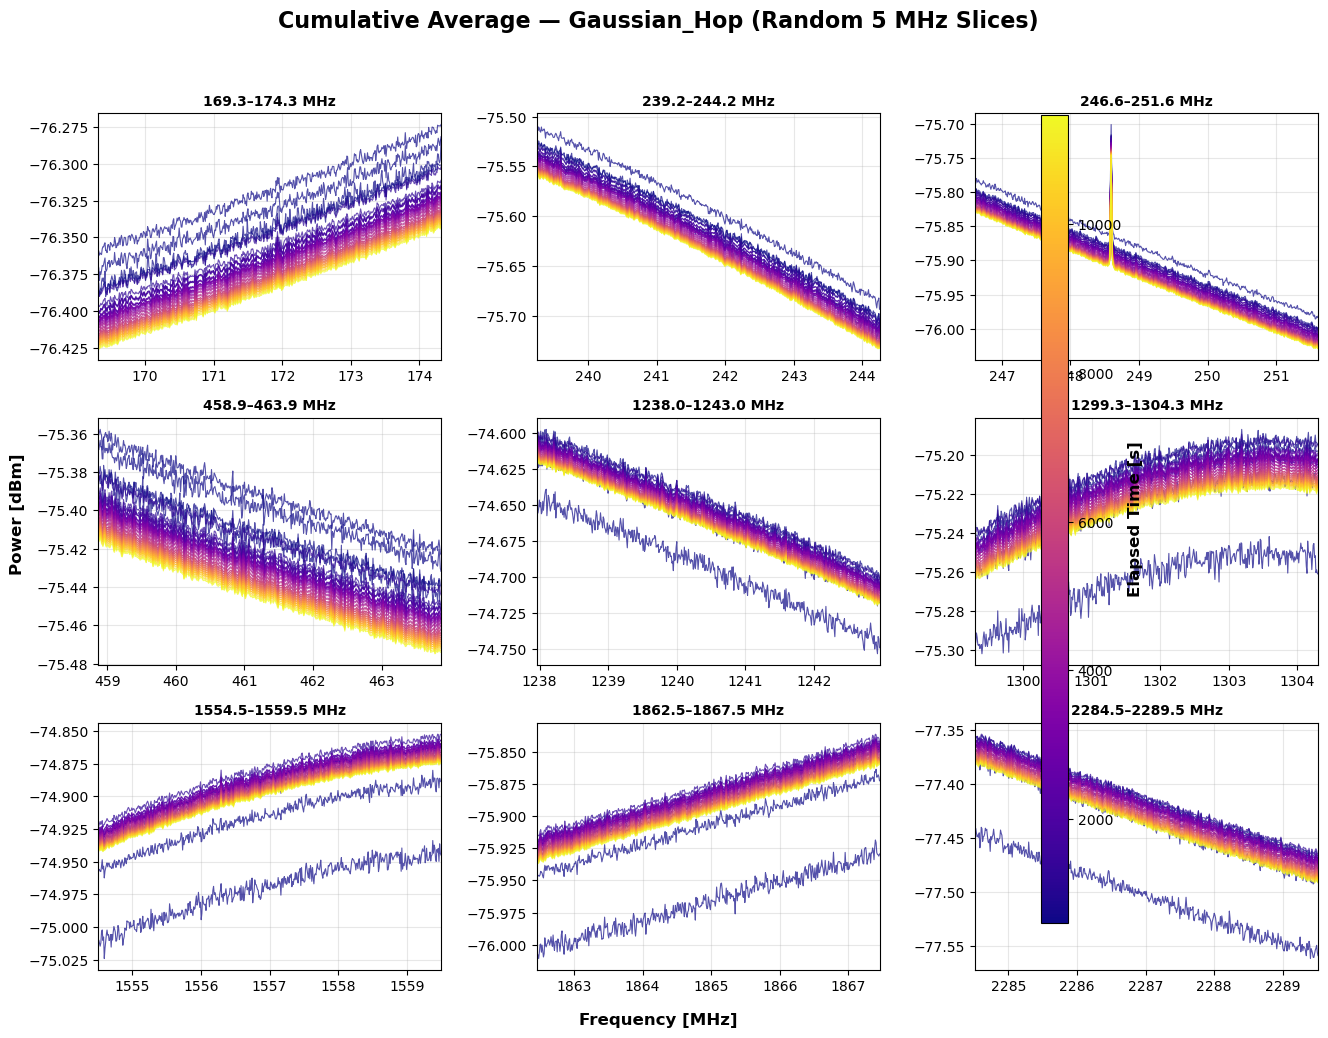

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import random
import glob
import os

path = "./"
method = "Gaussian_Hop"
MHz_window = 5.0
n_windows = 9
max_lines = 40

def load_spectra(method):
    files = sorted(glob.glob(os.path.join(path, f"partial_{method}_*.npz")))
    data = []
    for fn in files:
        try:
            d = np.load(fn)
            data.append((float(d["elapsed_seconds"]), d["F"], d["spec"]))
        except:
            print("Skipping:", fn)
    data.sort(key=lambda x: x[0])
    return data

def to_dBm(spec, R=50):
    return 10*np.log10(np.maximum(spec / (2*R*1e-3), 1e-20))

# -------------------------------
# Load data
# -------------------------------
data = load_spectra(method)
if len(data) == 0:
    raise ValueError("No data loaded for Gaussian_Hop")

all_elapsed_times = np.array([d[0] for d in data])
F_full = data[0][1]  # frequency reference

# Valid frequency range
f_min = F_full.min()
f_max = F_full.max() - MHz_window

# Random 5 MHz start frequencies
random_starts = sorted(random.sample(list(np.linspace(f_min, f_max, 2000)), n_windows))

# Grid layout
ncols = int(np.ceil(np.sqrt(n_windows)))
nrows = int(np.ceil(n_windows / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows), sharey=False)
axes = axes.flatten()

# Time colormap
norm = Normalize(vmin=all_elapsed_times.min(), vmax=all_elapsed_times.max())
cmap = plt.cm.plasma

# Subsample times to avoid overcrowding
if len(all_elapsed_times) > max_lines:
    step = len(all_elapsed_times) // max_lines
    plot_data = data[::step]
else:
    plot_data = data

# -------------------------------
# Plot each random window with cumulative average
# -------------------------------
for ax, f0 in zip(axes, random_starts):
    f1 = f0 + MHz_window
    y_values = []

    # Common frequency grid for this subplot
    freq_grid = np.linspace(f0, f1, 500)  # 500 points per 5 MHz slice
    cumulative_sum = np.zeros_like(freq_grid)

    for idx, (t, F, spec) in enumerate(plot_data):
        mask = (F >= f0) & (F <= f1)
        F_slice = F[mask]
        spec_slice = to_dBm(spec[mask])

        if len(F_slice) == 0:
            continue

        # Interpolate to common frequency grid
        spec_interp = np.interp(freq_grid, F_slice, spec_slice)

        # Cumulative sum / rolling average
        cumulative_sum += spec_interp
        avg_spec = cumulative_sum / (idx + 1)
        y_values.extend(avg_spec)

        ax.plot(freq_grid, avg_spec, color=cmap(norm(t)), linewidth=0.8, alpha=0.7)

    # Dynamic y-axis zoom
    if y_values:
        ymin, ymax = min(y_values), max(y_values)
        margin = 0.05*(ymax - ymin)
        ax.set_ylim(ymin - margin, ymax + margin)

    ax.set_xlim(f0, f1)
    ax.set_title(f"{f0:.1f}–{f1:.1f} MHz", fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Turn off unused axes
for ax in axes[len(random_starts):]:
    ax.axis('off')

# Global labels
fig.suptitle("Cumulative Average — Gaussian_Hop (Random 5 MHz Slices)", fontsize=16, fontweight='bold')
fig.supxlabel("Frequency [MHz]", fontsize=12, fontweight='bold')
fig.supylabel("Power [dBm]", fontsize=12, fontweight='bold')

# Colorbar on the right
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), pad=0.02, aspect=30)
cbar.set_label("Elapsed Time [s]", fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
outname = "gaussian_hop_random_5MHz_cumulative_avg_grid.png"
plt.savefig(outname, dpi=300, bbox_inches="tight")
print(f"Saved: {outname}")
plt.show()


/var/folders/y2/qh0xmfp57pg1gkfyt952g7ww0000gp/T/ipykernel_62019/2983719485.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.04, 0.92, 0.94])


Saved: gaussian_hop_random_5MHz_time_evolution_grid.png


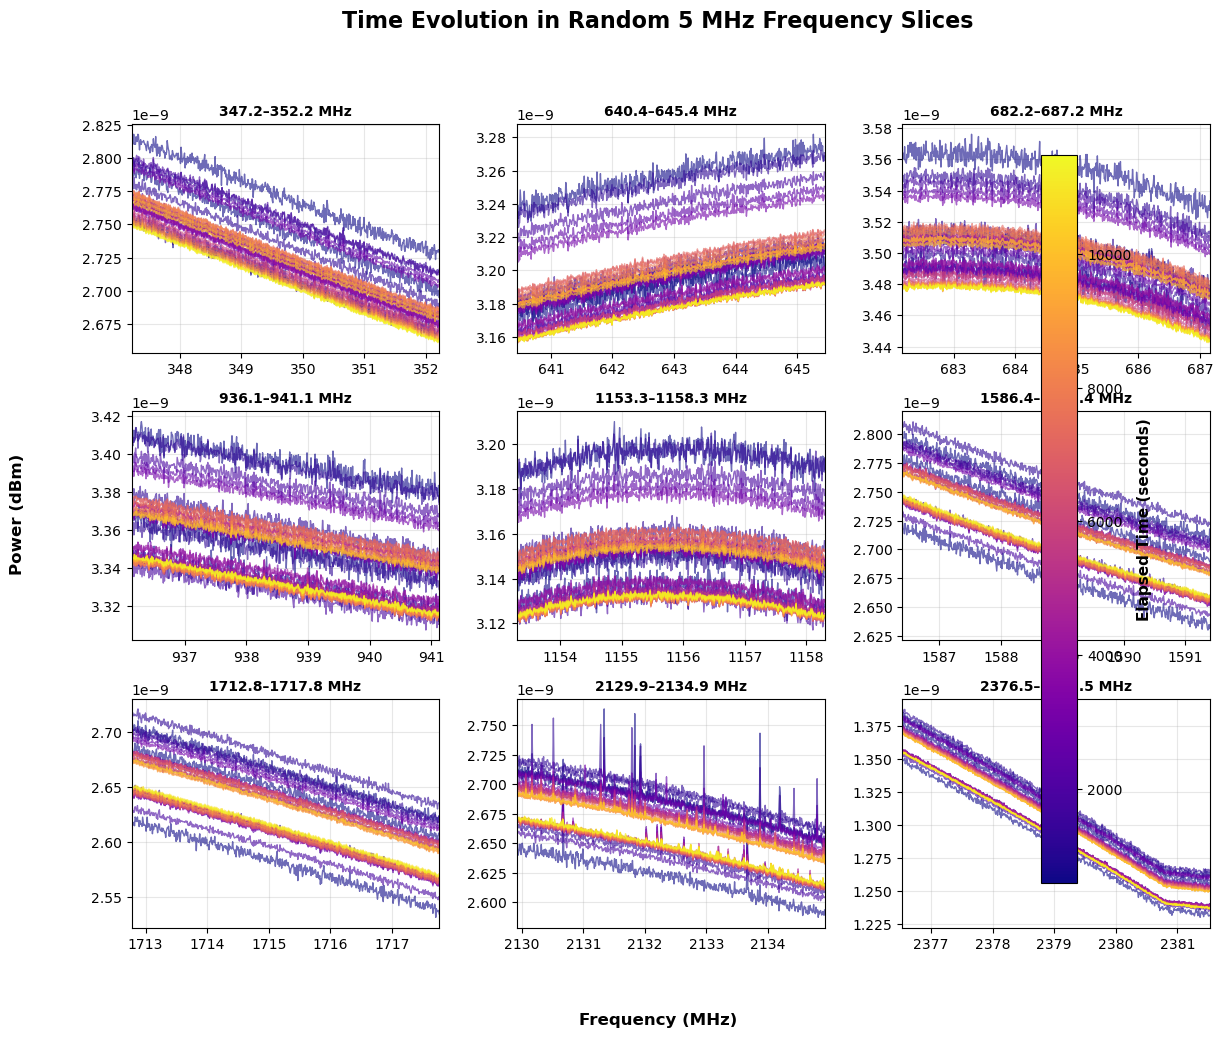

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import random
import math

MHz_window = 5.0
n_windows = 9
max_lines = 40

first_time = all_elapsed_times[0]
F_full = data_by_time[first_time]['F']

f_min = F_full.min()
f_max = F_full.max() - MHz_window

random_starts = sorted(
    random.sample(
        list(np.linspace(f_min, f_max, 2000)),
        n_windows
    )
)

ncols = int(np.ceil(np.sqrt(n_windows)))
nrows = int(np.ceil(n_windows / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4.5 * ncols, 3.5 * nrows),
    sharey=False
)

axes = axes.flatten()

norm = Normalize(vmin=min(all_elapsed_times), vmax=max(all_elapsed_times))
cmap = plt.cm.plasma

if len(all_elapsed_times) > max_lines:
    step = len(all_elapsed_times) // max_lines
    plot_times = all_elapsed_times[::step]
else:
    plot_times = all_elapsed_times

for ax, f0 in zip(axes, random_starts):
    f1 = f0 + MHz_window
    y_values = []

    for t in plot_times:
        data = data_by_time[t]
        F = data['F']
        spec = data['spec']

        mask = (F >= f0) & (F <= f1)
        y_values.extend(spec[mask])

        ax.plot(
            F[mask],
            spec[mask],
            color=cmap(norm(t)),
            linewidth=1.0,
            alpha=0.6
        )

    if y_values:
        ymin, ymax = min(y_values), max(y_values)
        margin = 0.05 * (ymax - ymin)
        ax.set_ylim(ymin - margin, ymax + margin)

    ax.set_xlim(f0, f1)
    ax.set_title(f"{f0:.1f}–{f1:.1f} MHz", fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

for ax in axes[len(random_starts):]:
    ax.axis('off')

fig.suptitle(
    "Time Evolution in Random 5 MHz Frequency Slices",
    fontsize=16,
    fontweight='bold'
)

fig.supxlabel("Frequency (MHz)", fontsize=12, fontweight='bold')
fig.supylabel("Power (dBm)", fontsize=12, fontweight='bold')

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.tolist(),
    location="right",
    pad=0.02,
    shrink=0.9
)

cbar.set_label("Elapsed Time (seconds)", fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0.04, 0.04, 0.92, 0.94])

outname = "gaussian_hop_random_5MHz_time_evolution_grid.png"
plt.savefig(outname, dpi=300, bbox_inches="tight")
print(f"Saved: {outname}")

plt.show()


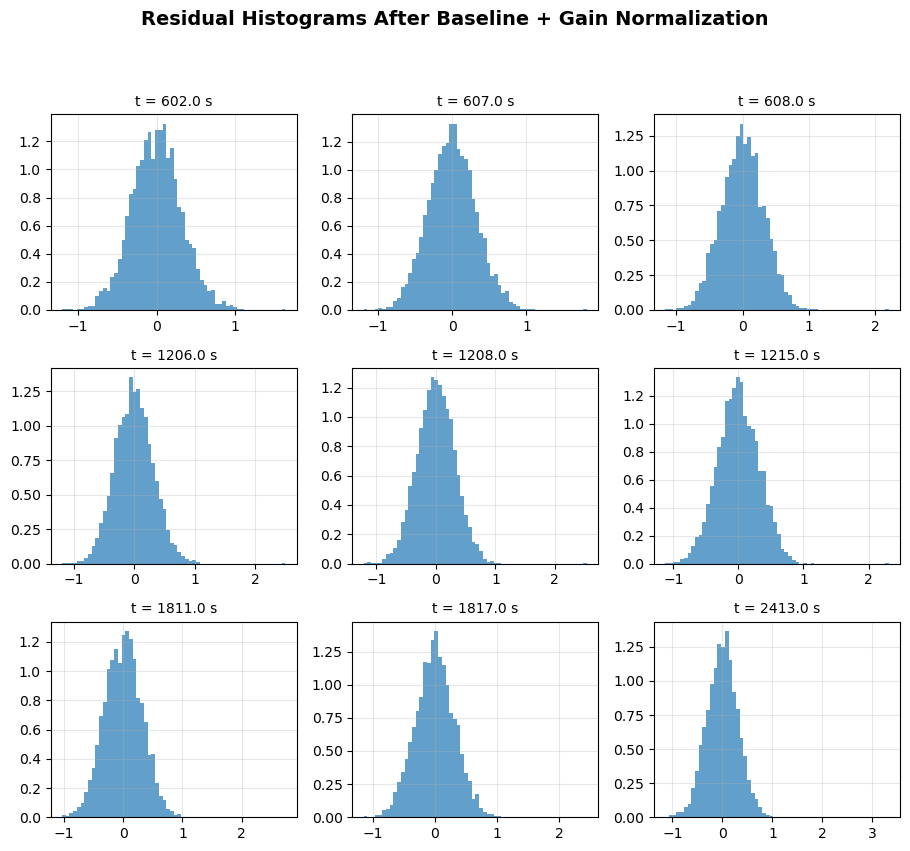

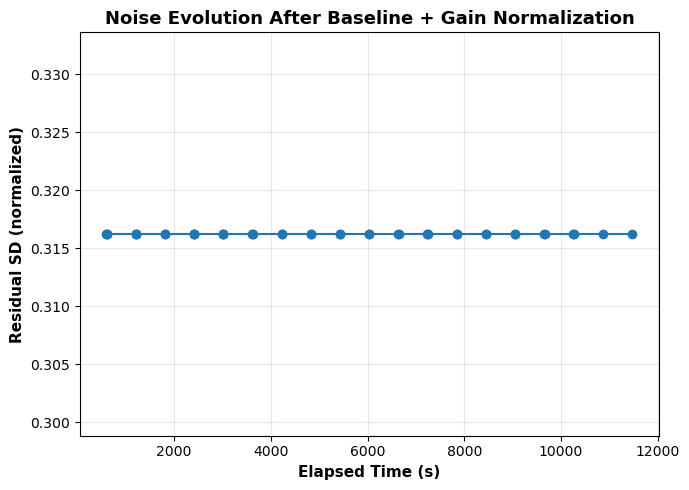

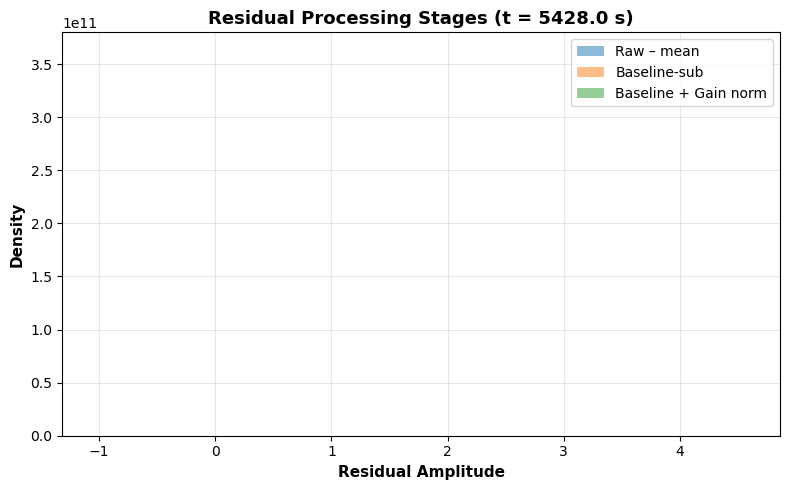

In [16]:
window_specs = {t: [] for t in plot_times}

for f0 in random_starts:
    f1 = f0 + MHz_window

    for t in plot_times:
        data = data_by_time[t]
        F = data['F']
        spec = data['spec']

        mask = (F >= f0) & (F <= f1)
        window_specs[t].append(spec[mask])


poly_order = 3

baseline_sub_specs = {}

for t in plot_times:
    specs = window_specs[t]
    residuals = []

    for spec in specs:
        x = np.arange(len(spec))
        p = np.polyfit(x, spec, poly_order)
        baseline = np.polyval(p, x)
        residuals.append(spec - baseline)

    baseline_sub_specs[t] = residuals


target_var = 0.10

gain_norm_specs = {}

for t in plot_times:
    residuals = baseline_sub_specs[t]
    scaled = []

    for r in residuals:
        v = np.var(r)
        scale = np.sqrt(target_var / v) if v > 0 else 1.0
        scaled.append(r * scale)

    gain_norm_specs[t] = scaled

target_var = 0.10

gain_norm_specs = {}

for t in plot_times:
    residuals = baseline_sub_specs[t]
    scaled = []

    for r in residuals:
        v = np.var(r)
        scale = np.sqrt(target_var / v) if v > 0 else 1.0
        scaled.append(r * scale)

    gain_norm_specs[t] = scaled

fig_hist, axes_hist = plt.subplots(3, 3, figsize=(10, 9))
axes_hist = axes_hist.flatten()

for ax, t in zip(axes_hist, plot_times[:9]):
    all_res = np.concatenate(gain_norm_specs[t])
    ax.hist(all_res, bins=60, density=True, alpha=0.7)
    ax.set_title(f"t = {t:.1f} s", fontsize=10)
    ax.grid(True, alpha=0.3)

for ax in axes_hist[len(plot_times[:9]):]:
    ax.axis("off")

fig_hist.suptitle("Residual Histograms After Baseline + Gain Normalization",
                  fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0.04, 0.04, 0.96, 0.94])
plt.show()

times = []
sds = []

for t in plot_times:
    all_res = np.concatenate(gain_norm_specs[t])
    times.append(t)
    sds.append(np.std(all_res))

times = np.array(times)
sds = np.array(sds)

fig_sd, ax_sd = plt.subplots(figsize=(7, 5))
ax_sd.plot(times, sds, "o-", linewidth=1.5)

ax_sd.set_xlabel("Elapsed Time (s)", fontsize=11, fontweight="bold")
ax_sd.set_ylabel("Residual SD (normalized)", fontsize=11, fontweight="bold")
ax_sd.set_title("Noise Evolution After Baseline + Gain Normalization",
                fontsize=13, fontweight="bold")

ax_sd.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

t0 = plot_times[len(plot_times)//2]

raw_res = []
base_res = []
gain_res = []

for spec in window_specs[t0]:
    raw_res.append(spec - np.mean(spec))

for r in baseline_sub_specs[t0]:
    base_res.append(r)

for r in gain_norm_specs[t0]:
    gain_res.append(r)

raw_res = np.concatenate(raw_res)
base_res = np.concatenate(base_res)
gain_res = np.concatenate(gain_res)

fig_stage, ax_stage = plt.subplots(figsize=(8, 5))

ax_stage.hist(raw_res, bins=80, density=True, alpha=0.5, label="Raw – mean")
ax_stage.hist(base_res, bins=80, density=True, alpha=0.5, label="Baseline-sub")
ax_stage.hist(gain_res, bins=80, density=True, alpha=0.5, label="Baseline + Gain norm")

ax_stage.set_xlabel("Residual Amplitude", fontsize=11, fontweight="bold")
ax_stage.set_ylabel("Density", fontsize=11, fontweight="bold")
ax_stage.set_title(f"Residual Processing Stages (t = {t0:.1f} s)",
                   fontsize=13, fontweight="bold")

ax_stage.legend()
ax_stage.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


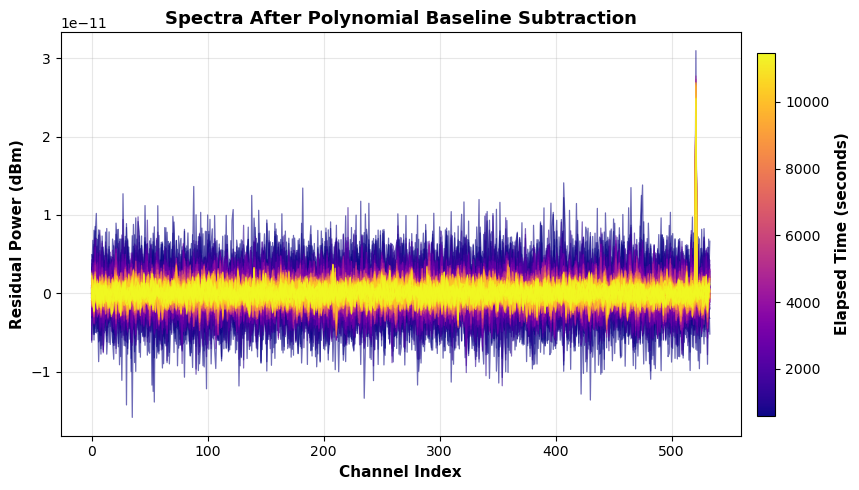

In [17]:
fig_base, ax_base = plt.subplots(figsize=(9, 5))

for t in plot_times:
    residuals = baseline_sub_specs[t]

    for r in residuals:
        x = np.arange(len(r))
        ax_base.plot(
            x,
            r,
            color=cmap(norm(t)),
            linewidth=0.9,
            alpha=0.6
        )

ax_base.set_xlabel("Channel Index", fontsize=11, fontweight="bold")
ax_base.set_ylabel("Residual Power (dBm)", fontsize=11, fontweight="bold")
ax_base.set_title("Spectra After Polynomial Baseline Subtraction",
                  fontsize=13, fontweight="bold")

ax_base.grid(True, alpha=0.3)

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig_base.colorbar(
    sm,
    ax=ax_base,
    location="right",
    pad=0.02,
    shrink=0.9
)

cbar.set_label("Elapsed Time (seconds)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


Has absolute timestamps: True
Timestamp field: timestamp


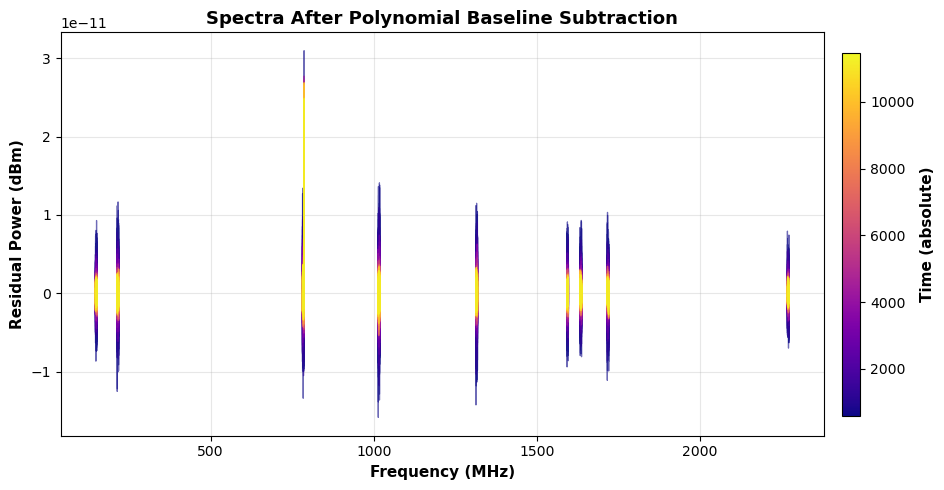

In [19]:
sample_t = plot_times[0]
sample_data = data_by_time[sample_t]

has_timestamp = False
timestamp_key = None

for k in sample_data.keys():
    if "time" in k.lower() or "timestamp" in k.lower() or "date" in k.lower():
        has_timestamp = True
        timestamp_key = k
        break

print("Has absolute timestamps:", has_timestamp)
if has_timestamp:
    print("Timestamp field:", timestamp_key)


fig_base, ax_base = plt.subplots(figsize=(10, 5))

for t in plot_times:
    residuals = baseline_sub_specs[t]
    data = data_by_time[t]
    F = data["F"]

    for r, f0 in zip(residuals, random_starts):
        f1 = f0 + MHz_window
        mask = (F >= f0) & (F <= f1)

        ax_base.plot(
            F[mask],
            r,
            color=cmap(norm(t)),
            linewidth=0.9,
            alpha=0.6
        )

ax_base.set_xlabel("Frequency (MHz)", fontsize=11, fontweight="bold")
ax_base.set_ylabel("Residual Power (dBm)", fontsize=11, fontweight="bold")
ax_base.set_title("Spectra After Polynomial Baseline Subtraction",
                  fontsize=13, fontweight="bold")

ax_base.grid(True, alpha=0.3)

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig_base.colorbar(
    sm,
    ax=ax_base,
    location="right",
    pad=0.02,
    shrink=0.9
)

if has_timestamp:
    cbar.set_label("Time (absolute)", fontsize=11, fontweight="bold")
else:
    cbar.set_label("Elapsed Time (seconds)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


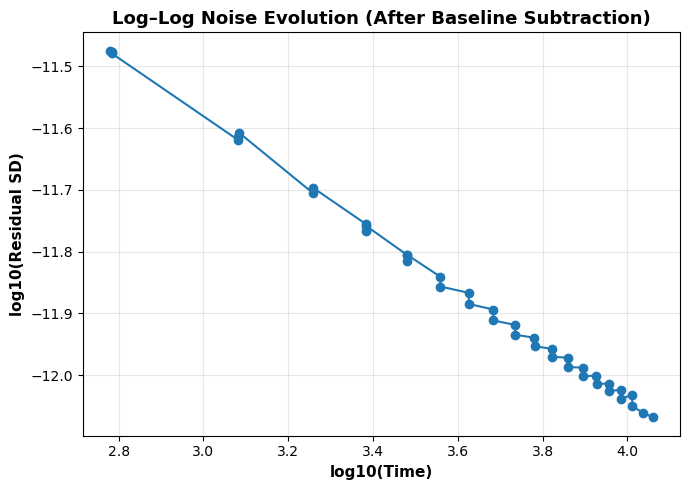

In [20]:
times = []
sds = []

for t in plot_times:
    all_res = np.concatenate(baseline_sub_specs[t])
    times.append(t)
    sds.append(np.std(all_res))

times = np.array(times)
sds = np.array(sds)

mask = (times > 0) & (sds > 0)

fig_log, ax_log = plt.subplots(figsize=(7, 5))
ax_log.plot(np.log10(times[mask]), np.log10(sds[mask]), "o-", linewidth=1.5)

ax_log.set_xlabel("log10(Time)", fontsize=11, fontweight="bold")
ax_log.set_ylabel("log10(Residual SD)", fontsize=11, fontweight="bold")
ax_log.set_title("Log–Log Noise Evolution (After Baseline Subtraction)",
                 fontsize=13, fontweight="bold")

ax_log.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Found 42 Gaussian Hop partial files
Loading: partial_Gaussian_Hop_10252s_20251125_020103.npz
Data keys: ['F', 'spec', 'counter', 'elapsed_seconds', 'timestamp']
Loading: partial_Gaussian_Hop_10268s_20251125_050130.npz
Loading: partial_Gaussian_Hop_10873s_20251125_051135.npz
Loading: partial_Gaussian_Hop_11477s_20251125_052139.npz
Loading: partial_Gaussian_Hop_1206s_20251125_023028.npz
Loading: partial_Gaussian_Hop_1208s_20251124_233019.npz
Loading: partial_Gaussian_Hop_1215s_20251124_223017.npz
Loading: partial_Gaussian_Hop_1811s_20251124_234022.npz
Loading: partial_Gaussian_Hop_1811s_20251125_024033.npz
Loading: partial_Gaussian_Hop_1817s_20251124_224019.npz
Loading: partial_Gaussian_Hop_2413s_20251124_235024.npz
Loading: partial_Gaussian_Hop_2415s_20251125_025037.npz
Loading: partial_Gaussian_Hop_2418s_20251124_225020.npz
Loading: partial_Gaussian_Hop_3016s_20251125_000027.npz
Loading: partial_Gaussian_Hop_3019s_20251125_030041.npz
Loading: partial_Gaussian_Hop_3020s_20251124_230022.

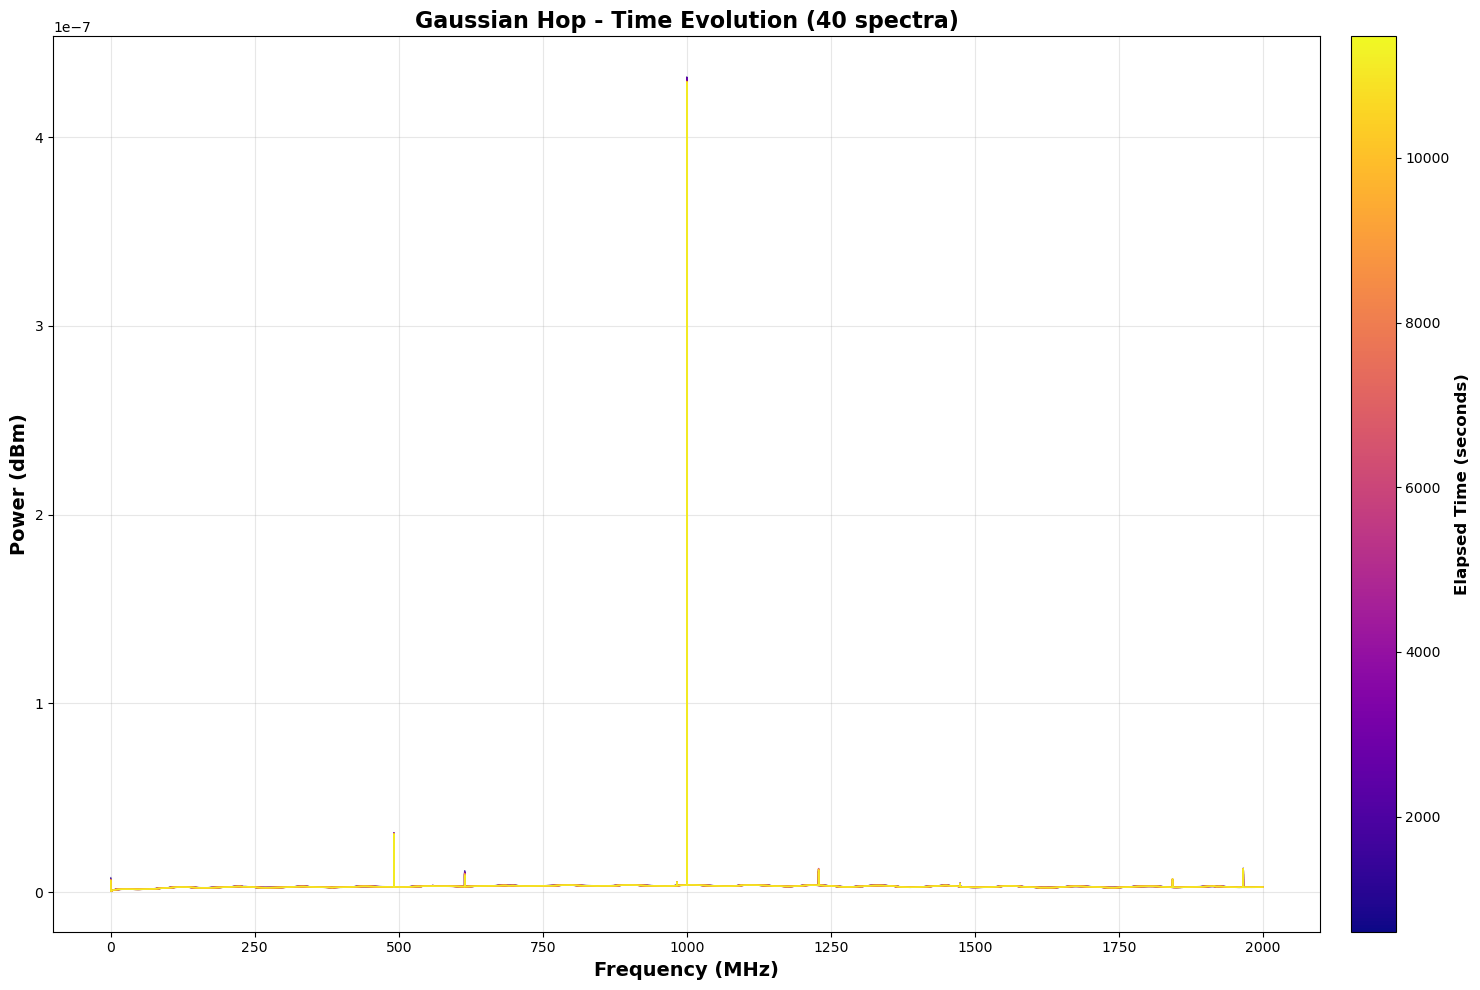

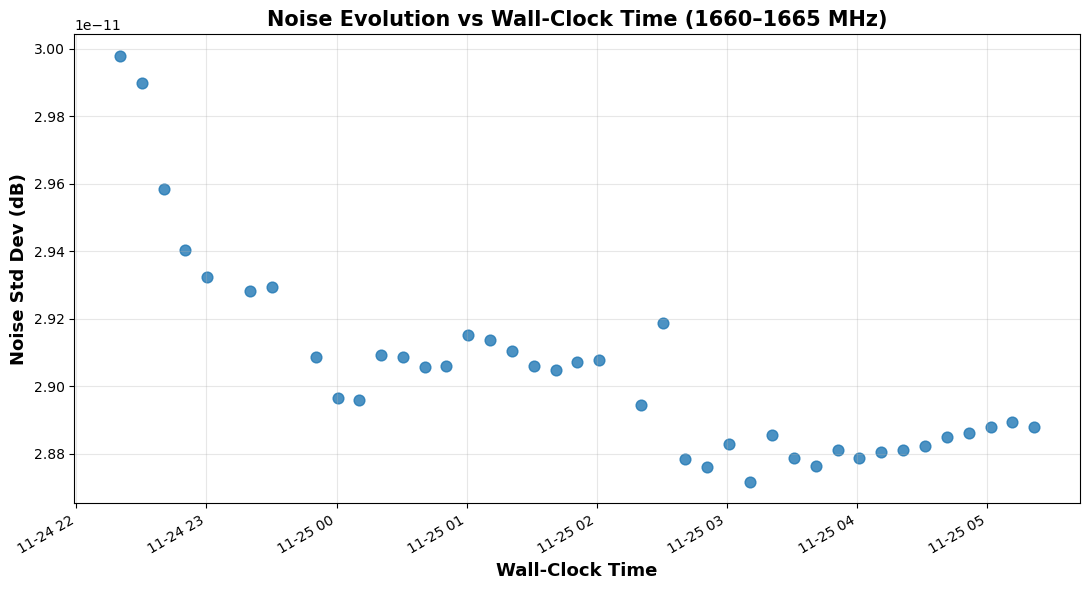


SUMMARY (Wall-Clock Time)
First timestamp: 2025-11-25 02:20:24
Last timestamp:  2025-11-25 05:21:39
Total duration:  3.02 hours
Initial noise std dev: 0.0000 dB
Final noise std dev:   0.0000 dB
Noise improvement factor: 1.00x


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import glob
import os
from datetime import datetime

pattern = 'partial_Gaussian_Hop_*.npz'
files = sorted(glob.glob(pattern))

print(f"Found {len(files)} Gaussian Hop partial files")

data_by_time = {}

for filename in files:
    print(f"Loading: {os.path.basename(filename)}")

    data = np.load(filename)

    if len(data_by_time) == 0:
        print(f"Data keys: {data.files}")

    F = data['F']
    spec = data['spec']

    if np.max(F) > 1e6:
        F = F / 1e6

    if 'elapsed_seconds' in data:
        elapsed_time_sec = int(data['elapsed_seconds'].item())
    else:
        parts = os.path.basename(filename).split('_')
        elapsed_time_str = parts[3].replace('s', '')
        elapsed_time_sec = int(elapsed_time_str)

    if 'timestamp' in data:
        ts_raw = data['timestamp'].item()
        ts_dt = datetime.fromisoformat(str(ts_raw))
    else:
        parts = os.path.basename(filename).split('_')
        datestr = parts[4]
        timestr = parts[5].replace('.npz', '')
        ts_dt = datetime.strptime(datestr + timestr, "%Y%m%d%H%M%S")

    data_by_time[elapsed_time_sec] = {
        'F': F,
        'spec': spec,
        'filename': filename,
        'elapsed_seconds': elapsed_time_sec,
        'timestamp': ts_dt
    }

all_elapsed_times = sorted(data_by_time.keys())

print(f"\nTotal time points: {len(all_elapsed_times)}")
print(f"Time range: {all_elapsed_times[0]}s to {all_elapsed_times[-1]}s")
print(f"Time range: {all_elapsed_times[0]/60:.1f}min to {all_elapsed_times[-1]/3600:.1f}hours")

norm = Normalize(vmin=min(all_elapsed_times), vmax=max(all_elapsed_times))
cmap = plt.cm.plasma

fig, ax = plt.subplots(figsize=(16, 10))

plot_times = all_elapsed_times

for elapsed_time_sec in plot_times:
    entry = data_by_time[elapsed_time_sec]
    F = entry['F']
    spec = entry['spec']

    color = cmap(norm(elapsed_time_sec))

    freq_mask = (F >= 0) & (F <= 2000)
    F_filtered = F[freq_mask]
    spec_filtered = spec[freq_mask]

    ax.plot(F_filtered, spec_filtered, color=color, linewidth=1.0, alpha=0.6)

ax.set_xlabel('Frequency (MHz)', fontsize=14, fontweight='bold')
ax.set_ylabel('Power (dBm)', fontsize=14, fontweight='bold')
ax.set_title(f'Gaussian Hop - Time Evolution ({len(all_elapsed_times)} spectra)', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Elapsed Time (seconds)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('gaussian_hop_time_evolution_full.png', dpi=300, bbox_inches='tight')
plt.show()

noise_times_dt = []
noise_std = []

for elapsed_time_sec in all_elapsed_times:
    entry = data_by_time[elapsed_time_sec]
    F = entry['F']
    spec = entry['spec']
    ts_dt = entry['timestamp']

    noise_mask = (F >= 1660) & (F <= 1665)
    noise_data = spec[noise_mask]

    noise_times_dt.append(ts_dt)
    noise_std.append(np.std(noise_data))

noise_times_dt = np.array(noise_times_dt)
noise_std = np.array(noise_std)

fig_tod, ax_tod = plt.subplots(figsize=(11, 6))

ax_tod.scatter(noise_times_dt, noise_std, s=60, alpha=0.8)

ax_tod.set_xlabel('Wall-Clock Time', fontsize=13, fontweight='bold')
ax_tod.set_ylabel('Noise Std Dev (dB)', fontsize=13, fontweight='bold')
ax_tod.set_title('Noise Evolution vs Wall-Clock Time (1660–1665 MHz)', fontsize=15, fontweight='bold')

ax_tod.grid(True, alpha=0.3)
fig_tod.autofmt_xdate()

plt.tight_layout()
plt.savefig('gaussian_hop_noise_vs_wallclock.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("SUMMARY (Wall-Clock Time)")
print("="*60)
print(f"First timestamp: {noise_times_dt[0]}")
print(f"Last timestamp:  {noise_times_dt[-1]}")
print(f"Total duration:  {(noise_times_dt[-1] - noise_times_dt[0]).total_seconds()/3600:.2f} hours")
print(f"Initial noise std dev: {noise_std[0]:.4f} dB")
print(f"Final noise std dev:   {noise_std[-1]:.4f} dB")
print(f"Noise improvement factor: {noise_std[0]/noise_std[-1]:.2f}x")
print("="*60)


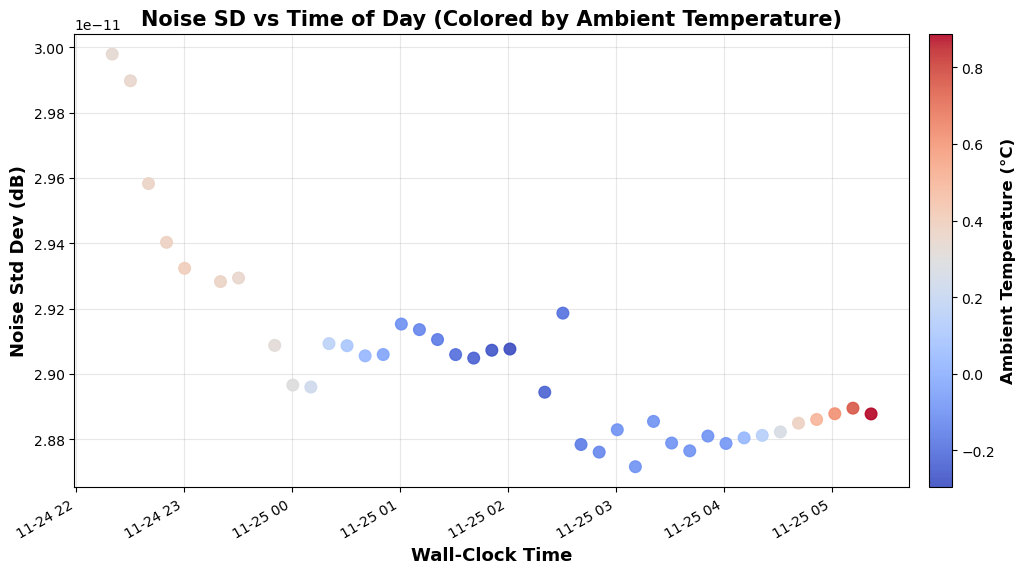

In [22]:
fig_tod, ax_tod = plt.subplots(figsize=(11, 6))

# background temperature field
sc = ax_tod.scatter(
    noise_times_dt,
    noise_std,
    c=temp_interp,
    cmap="coolwarm",
    s=70,
    alpha=0.9,
    zorder=3
)

ax_tod.set_xlabel("Wall-Clock Time", fontsize=13, fontweight="bold")
ax_tod.set_ylabel("Noise Std Dev (dB)", fontsize=13, fontweight="bold")
ax_tod.set_title("Noise SD vs Time of Day (Colored by Ambient Temperature)",
                 fontsize=15, fontweight="bold")

ax_tod.grid(True, alpha=0.3)
fig_tod.autofmt_xdate()

cbarT = fig_tod.colorbar(sc, ax=ax_tod, pad=0.02)
cbarT.set_label("Ambient Temperature (°C)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


Selected quiet band: 1496.50–1501.50 MHz


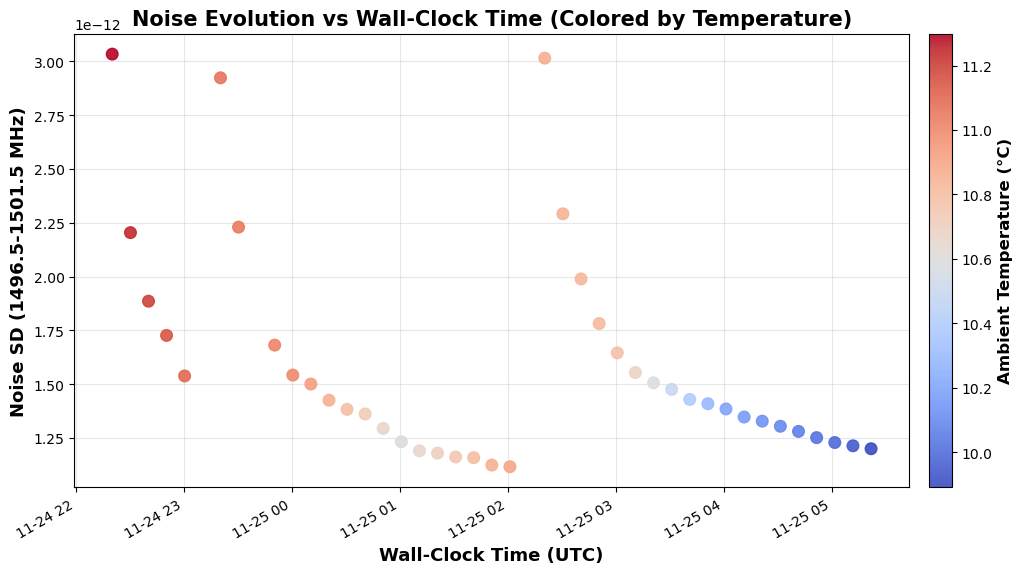


SUMMARY (Wall-Clock Time)
First timestamp: 2025-11-25 02:01:03
Last timestamp:  2025-11-25 04:51:25
Total duration:  2.84 hours
Initial noise SD: 0.0000
Final noise SD:   0.0000
Noise improvement factor: 0.89x
Correlation SD vs Temperature: 0.552


In [24]:
import requests
import pandas as pd

# ------------------------------------------------------------
# 1) Auto-select quiet 5-MHz band based on min std dev
# ------------------------------------------------------------
F = list(data_by_time.values())[0]['F']  # assume all F arrays identical
all_specs = [entry['spec'] for entry in data_by_time.values()]
band_edges = np.linspace(F.min(), F.max()-5.0, 60)
band_stds = []

for f0 in band_edges:
    f1 = f0 + 5.0
    stds_here = []
    mask = (F >= f0) & (F <= f1)
    if mask.sum() < 10:
        band_stds.append(np.inf)
        continue
    for spec in all_specs:
        stds_here.append(np.std(spec[mask]))
    band_stds.append(np.median(stds_here))

band_edges = np.array(band_edges)
band_stds = np.array(band_stds)
best_idx = np.argmin(band_stds)
f0_best = band_edges[best_idx]
f1_best = f0_best + 5.0
print(f"Selected quiet band: {f0_best:.2f}–{f1_best:.2f} MHz")
noise_mask = (F >= f0_best) & (F <= f1_best)

# ------------------------------------------------------------
# 2) Compute noise SD vs wall-clock time
# ------------------------------------------------------------
noise_times_dt = [entry['timestamp'] for entry in data_by_time.values()]
noise_std = [np.std(entry['spec'][noise_mask]) for entry in data_by_time.values()]

noise_times_dt = np.array(noise_times_dt)
noise_std = np.array(noise_std)

# ------------------------------------------------------------
# 3) Fetch hourly ambient temperature from Open-Meteo
# ------------------------------------------------------------
lat, lon = 37.4275, -122.1697  # replace with your site
t_start = noise_times_dt.min().strftime("%Y-%m-%d")
t_end   = noise_times_dt.max().strftime("%Y-%m-%d")

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={t_start}&end_date={t_end}"
    "&hourly=temperature_2m&timezone=UTC"
)
resp = requests.get(url, timeout=30)
resp.raise_for_status()
data = resp.json()
temp_times = pd.to_datetime(data["hourly"]["time"], utc=True).to_pydatetime()
temp_vals = np.array(data["hourly"]["temperature_2m"])

# Interpolate temperature onto spectrum timestamps
temp_interp = np.interp(
    [dt.timestamp() for dt in noise_times_dt],
    [dt.timestamp() for dt in temp_times],
    temp_vals
)

# ------------------------------------------------------------
# 4) Scatter plot Noise SD vs wall-clock time with temperature gradient
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(
    noise_times_dt,
    noise_std,
    c=temp_interp,
    cmap="coolwarm",
    s=70,
    alpha=0.9,
    zorder=3
)
ax.set_xlabel("Wall-Clock Time (UTC)", fontsize=13, fontweight="bold")
ax.set_ylabel(f"Noise SD ({f0_best:.1f}-{f1_best:.1f} MHz)", fontsize=13, fontweight="bold")
ax.set_title("Noise Evolution vs Wall-Clock Time (Colored by Temperature)", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Ambient Temperature (°C)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("gaussian_hop_noise_vs_wallclock_temp.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5) Optional: Print summary statistics
# ------------------------------------------------------------
rho = np.corrcoef(noise_std, temp_interp)[0, 1]
print("\n" + "="*60)
print("SUMMARY (Wall-Clock Time)")
print("="*60)
print(f"First timestamp: {noise_times_dt[0]}")
print(f"Last timestamp:  {noise_times_dt[-1]}")
print(f"Total duration:  {(noise_times_dt[-1] - noise_times_dt[0]).total_seconds()/3600:.2f} hours")
print(f"Initial noise SD: {noise_std[0]:.4f}")
print(f"Final noise SD:   {noise_std[-1]:.4f}")
print(f"Noise improvement factor: {noise_std[0]/noise_std[-1]:.2f}x")
print(f"Correlation SD vs Temperature: {rho:.3f}")
print("="*60)


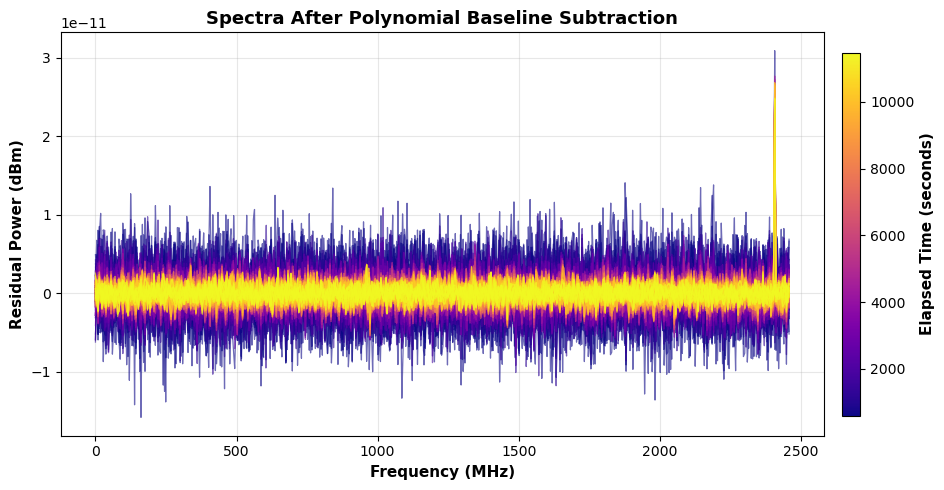

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import interp1d

# -------------------------------
# ASSUMED INPUTS
# -------------------------------
# data_by_time: dictionary with keys = elapsed_seconds
# Each entry contains:
#   'F': full frequency array in MHz
#   'spec': full spectrum
#   'timestamp': datetime object
# baseline_sub_specs: dictionary keyed by elapsed_seconds
#   Each entry = list of residual arrays (after baseline subtraction)
# plot_times: list of elapsed_seconds to plot
# norm, cmap: for color mapping by elapsed time
# -------------------------------

fig_base, ax_base = plt.subplots(figsize=(10, 5))

for t in plot_times:
    residuals = baseline_sub_specs[t]       # list of residuals for this time
    F_full = data_by_time[t]['F']           # full frequency array

    for r in residuals:
        # Interpolate residual onto full frequency axis if lengths mismatch
        if len(r) != len(F_full):
            f_orig = np.linspace(F_full[0], F_full[-1], len(r))
            r_interp = interp1d(f_orig, r, kind='linear')(F_full)
        else:
            r_interp = r

        ax_base.plot(
            F_full,
            r_interp,
            color=cmap(norm(t)),
            linewidth=0.9,
            alpha=0.6
        )

ax_base.set_xlabel("Frequency (MHz)", fontsize=11, fontweight="bold")
ax_base.set_ylabel("Residual Power (dBm)", fontsize=11, fontweight="bold")
ax_base.set_title("Spectra After Polynomial Baseline Subtraction", fontsize=13, fontweight="bold")
ax_base.grid(True, alpha=0.3)

# Colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig_base.colorbar(
    sm,
    ax=ax_base,
    location="right",
    pad=0.02,
    shrink=0.9
)
cbar.set_label("Elapsed Time (seconds)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


/var/folders/y2/qh0xmfp57pg1gkfyt952g7ww0000gp/T/ipykernel_62019/1370867162.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.04, 0.75, 0.94])


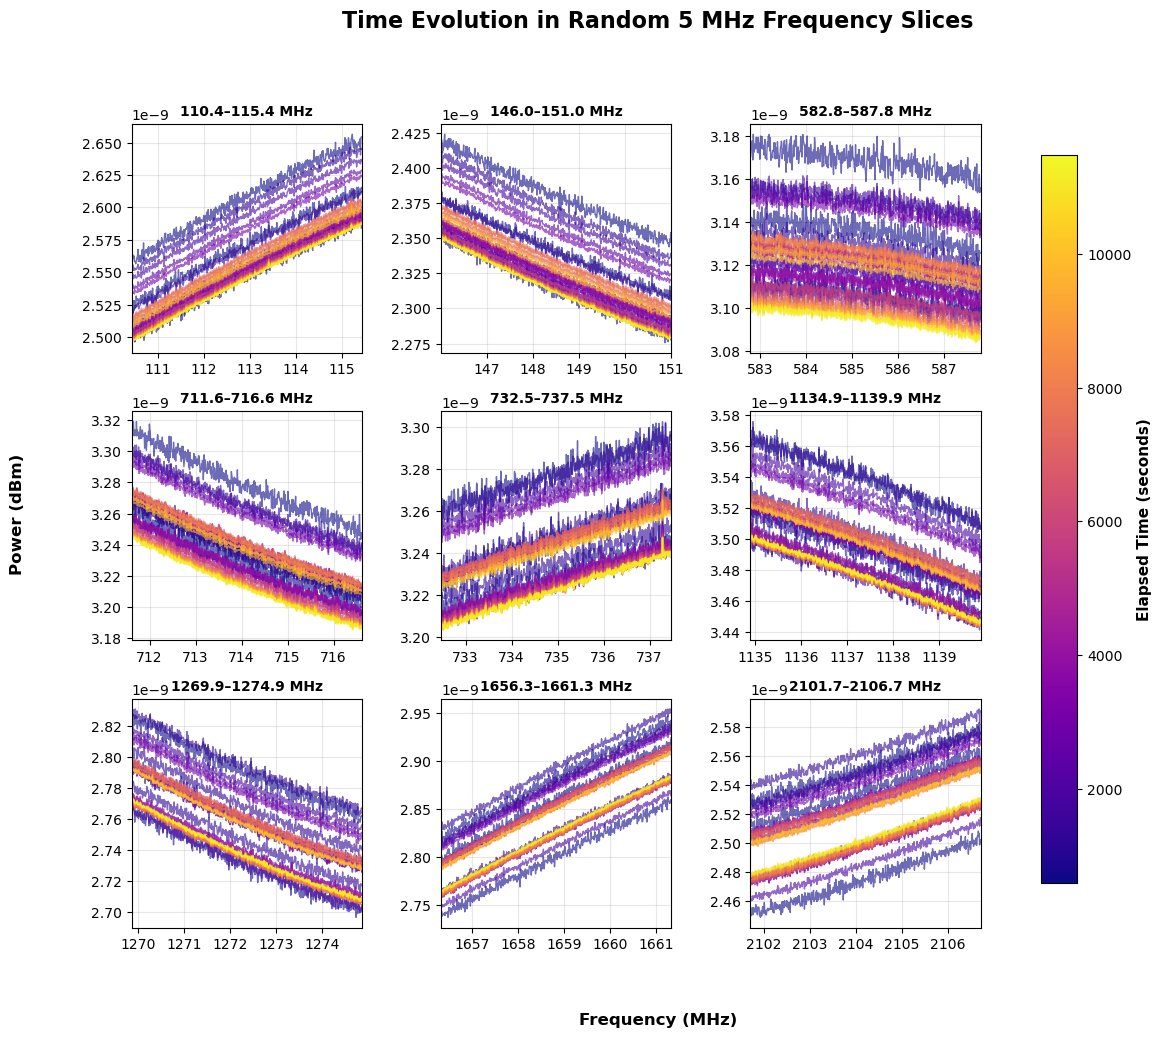

/var/folders/y2/qh0xmfp57pg1gkfyt952g7ww0000gp/T/ipykernel_62019/1370867162.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.04, 0.75, 0.94])


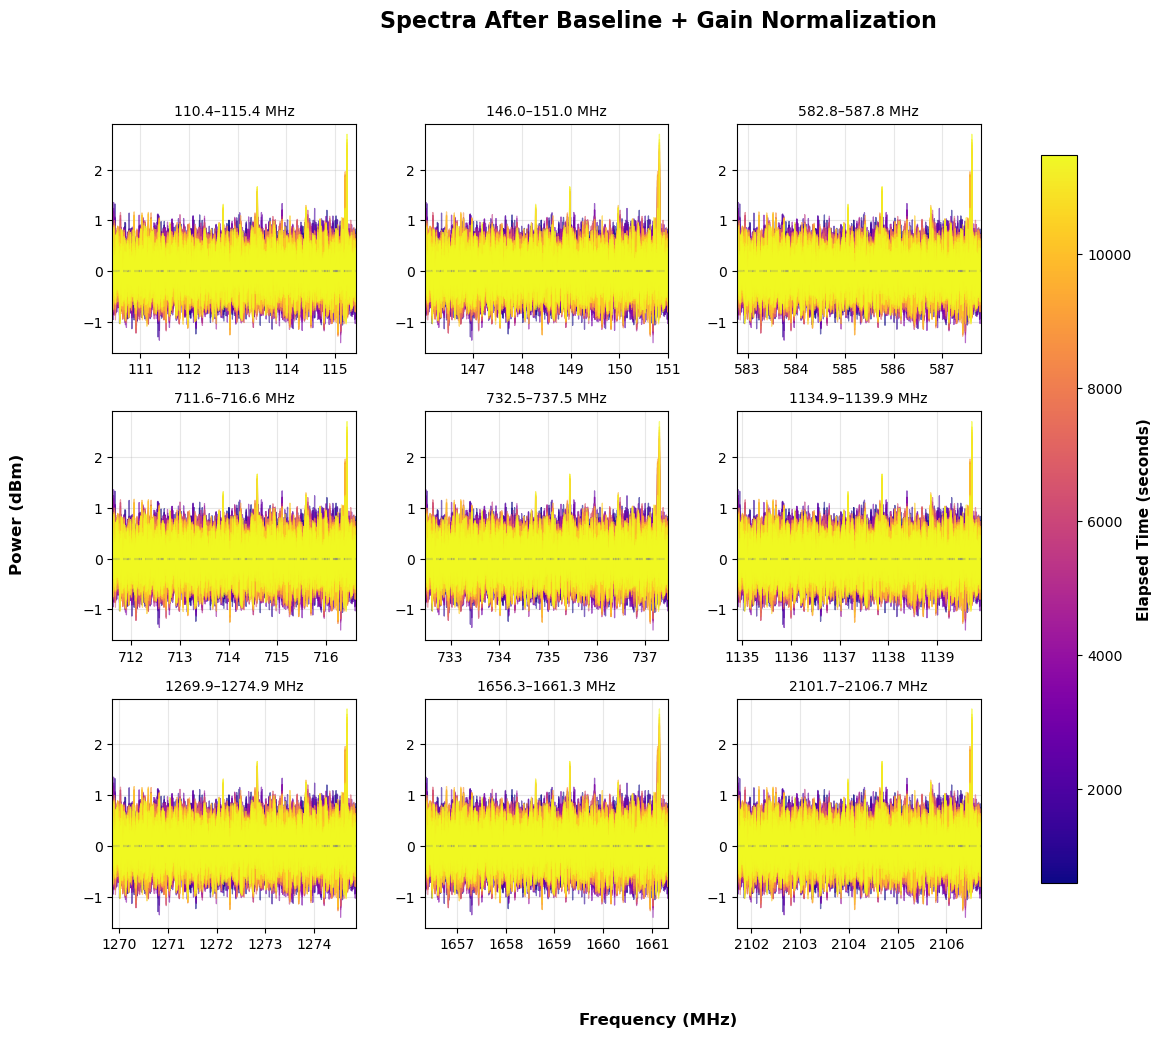

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import random

# -----------------------------
# PARAMETERS
# -----------------------------
MHz_window = 5.0
n_windows = 9
max_lines = 40
poly_order = 3
target_var = 0.10

first_time = all_elapsed_times[0]
F_full = data_by_time[first_time]['F']
f_min = F_full.min()
f_max = F_full.max() - MHz_window

random_starts = sorted(random.sample(list(np.linspace(f_min, f_max, 2000)), n_windows))
ncols = int(np.ceil(np.sqrt(n_windows)))
nrows = int(np.ceil(n_windows / ncols))

fig_grid, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows))
axes = axes.flatten()

norm = Normalize(vmin=min(all_elapsed_times), vmax=max(all_elapsed_times))
cmap = plt.cm.plasma

if len(all_elapsed_times) > max_lines:
    step = len(all_elapsed_times) // max_lines
    plot_times = all_elapsed_times[::step]
else:
    plot_times = all_elapsed_times

# -----------------------------
# PLOT RAW SPECTRA IN RANDOM WINDOWS
# -----------------------------
for ax, f0 in zip(axes, random_starts):
    f1 = f0 + MHz_window
    y_values = []

    for t in plot_times:
        data = data_by_time[t]
        F = data['F']
        spec = data['spec']

        mask = (F >= f0) & (F <= f1)
        y_values.extend(spec[mask])

        ax.plot(F[mask], spec[mask], color=cmap(norm(t)), linewidth=1.0, alpha=0.6)

    if y_values:
        ymin, ymax = min(y_values), max(y_values)
        margin = 0.05 * (ymax - ymin)
        ax.set_ylim(ymin - margin, ymax + margin)

    ax.set_xlim(f0, f1)
    ax.set_title(f"{f0:.1f}–{f1:.1f} MHz", fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

for ax in axes[len(random_starts):]:
    ax.axis('off')

fig_grid.suptitle("Time Evolution in Random 5 MHz Frequency Slices", fontsize=16, fontweight='bold')
fig_grid.supxlabel("Frequency (MHz)", fontsize=12, fontweight='bold')
fig_grid.supylabel("Power (dBm)", fontsize=12, fontweight='bold')

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig_grid.colorbar(sm, ax=axes.tolist(), location="right", pad=0.02, shrink=0.9)
cbar.set_label("Elapsed Time (seconds)", fontsize=11, fontweight="bold")

plt.tight_layout(rect=[0.04, 0.04, 0.75, 0.94])
plt.show()

# -----------------------------
# COMPUTE BASELINE, RESIDUALS, AND GAIN NORMALIZED
# -----------------------------
window_specs = {t: [] for t in plot_times}
baseline_sub_specs = {}
baseline_specs = {}
gain_norm_specs = {}

for f0 in random_starts:
    f1 = f0 + MHz_window

    for t in plot_times:
        data = data_by_time[t]
        F = data['F']
        spec = data['spec']
        mask = (F >= f0) & (F <= f1)
        spec_window = spec[mask]
        window_specs[t].append(spec_window)

# Baseline subtraction and gain normalization
for t in plot_times:
    residuals = []
    baselines = []
    scaled = []

    for spec in window_specs[t]:
        x = np.arange(len(spec))
        p = np.polyfit(x, spec, poly_order)
        baseline = np.polyval(p, x)
        residual = spec - baseline
        residuals.append(residual)
        baselines.append(baseline)

        # gain normalization
        var_r = np.var(residual)
        scale = np.sqrt(target_var / var_r) if var_r > 0 else 1.0
        scaled.append(residual * scale)

    baseline_sub_specs[t] = residuals
    baseline_specs[t] = baselines
    gain_norm_specs[t] = scaled

# -----------------------------
# PLOT BASELINE AND NORMALIZED SPECTRA
# -----------------------------
fig_base, axes_base = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows))
axes_base = axes_base.flatten()

for ax, f0 in zip(axes_base, random_starts):
    f1 = f0 + MHz_window

    for t in plot_times:
        # original baseline
        for b, r_scaled in zip(baseline_specs[t], gain_norm_specs[t]):
            # frequency array for this slice
            F_slice = np.linspace(f0, f1, len(b))
            # baseline
            ax.plot(F_slice, b, color='grey', linestyle='--', alpha=0.5)
            # baseline + gain-normalized residual
            ax.plot(F_slice, b + r_scaled, color=cmap(norm(t)), linewidth=0.9, alpha=0.6)

    ax.set_xlim(f0, f1)
    ax.set_title(f"{f0:.1f}–{f1:.1f} MHz", fontsize=10)
    ax.grid(True, alpha=0.3)

for ax in axes_base[len(random_starts):]:
    ax.axis('off')

fig_base.suptitle("Spectra After Baseline + Gain Normalization", fontsize=16, fontweight='bold')
fig_base.supxlabel("Frequency (MHz)", fontsize=12, fontweight='bold')
fig_base.supylabel("Power (dBm)", fontsize=12, fontweight='bold')

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig_base.colorbar(sm, ax=axes_base.tolist(), location="right", pad=0.02, shrink=0.9)
cbar.set_label("Elapsed Time (seconds)", fontsize=11, fontweight="bold")

plt.tight_layout(rect=[0.04, 0.04, 0.75, 0.94])
plt.show()


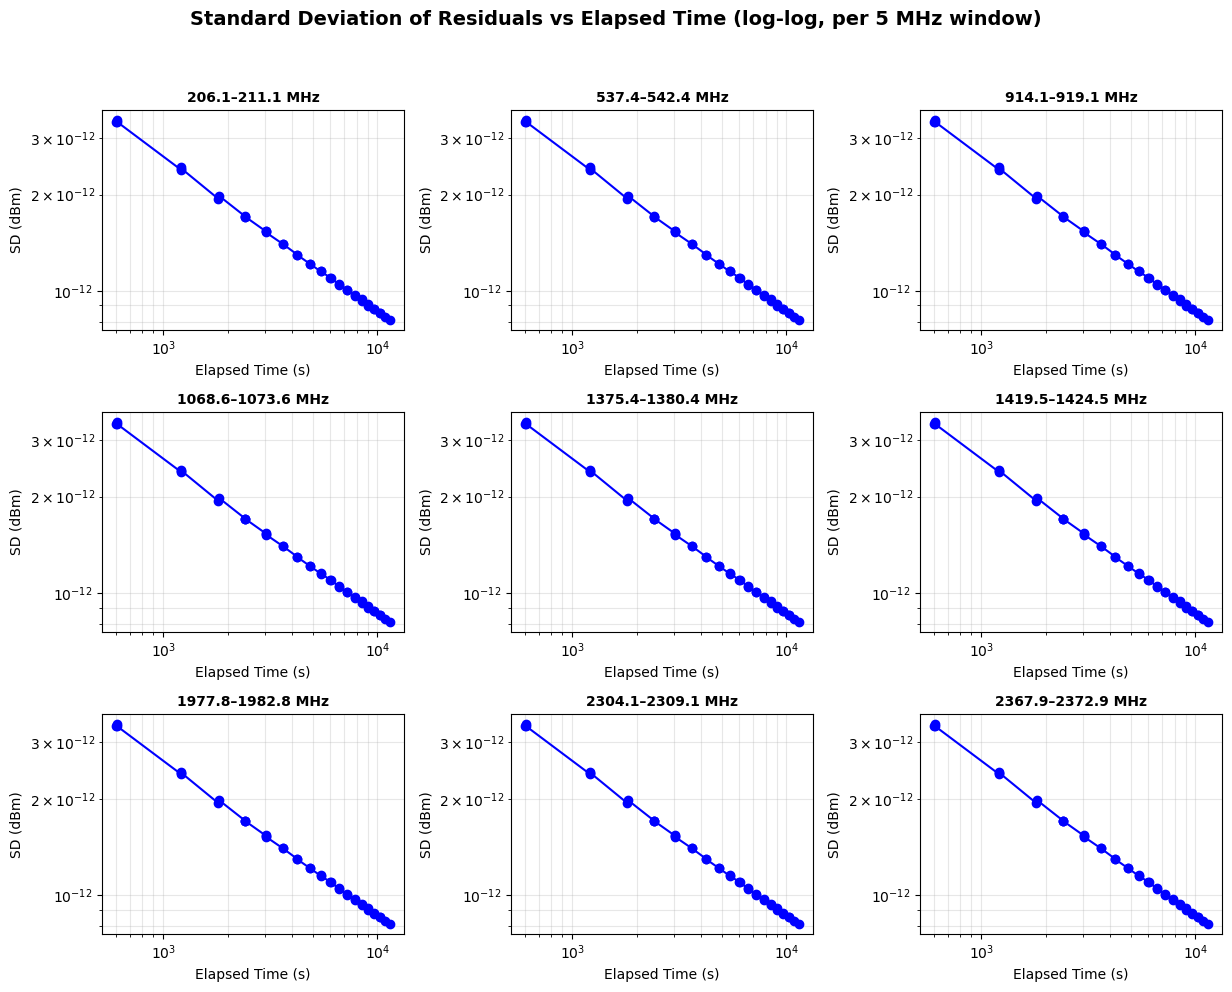

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import random

# -----------------------------
# PARAMETERS
# -----------------------------
MHz_window = 5.0
n_windows = 9
max_lines = 40

first_time = all_elapsed_times[0]
F_full = data_by_time[first_time]['F']
f_min = F_full.min()
f_max = F_full.max() - MHz_window

random_starts = sorted(random.sample(list(np.linspace(f_min, f_max, 2000)), n_windows))
ncols = int(np.ceil(np.sqrt(n_windows)))
nrows = int(np.ceil(n_windows / ncols))

if len(all_elapsed_times) > max_lines:
    step = len(all_elapsed_times) // max_lines
    plot_times = all_elapsed_times[::step]
else:
    plot_times = all_elapsed_times

# -----------------------------
# COMPUTE SDs FOR EACH WINDOW
# -----------------------------
window_sd = {f0: [] for f0 in random_starts}

for f0 in random_starts:
    f1 = f0 + MHz_window
    for t in plot_times:
        residuals = baseline_sub_specs[t]
        sd_list = []
        for r in residuals:
            F_slice = np.linspace(f0, f1, len(r))
            mask = (F_slice >= f0) & (F_slice <= f1)
            sd_list.append(np.std(r[mask]))
        window_sd[f0].append(np.mean(sd_list))

# -----------------------------
# PLOT SD VS TIME GRID (log-log)
# -----------------------------
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows), sharey=False)
axes = axes.flatten()

for ax, f0 in zip(axes, random_starts):
    ax.plot(plot_times, window_sd[f0], marker='o', linestyle='-', color='blue')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f"{f0:.1f}–{f0 + MHz_window:.1f} MHz", fontsize=10, fontweight='bold')
    ax.set_xlabel("Elapsed Time (s)", fontsize=10)
    ax.set_ylabel("SD (dBm)", fontsize=10)
    ax.grid(True, alpha=0.3, which='both')

for ax in axes[len(random_starts):]:
    ax.axis('off')

fig.suptitle("Standard Deviation of Residuals vs Elapsed Time (log-log, per 5 MHz window)",
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0.04, 0.04, 0.96, 0.95])
plt.show()


/var/folders/y2/qh0xmfp57pg1gkfyt952g7ww0000gp/T/ipykernel_62019/36119806.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.04, 0.96, 0.95])


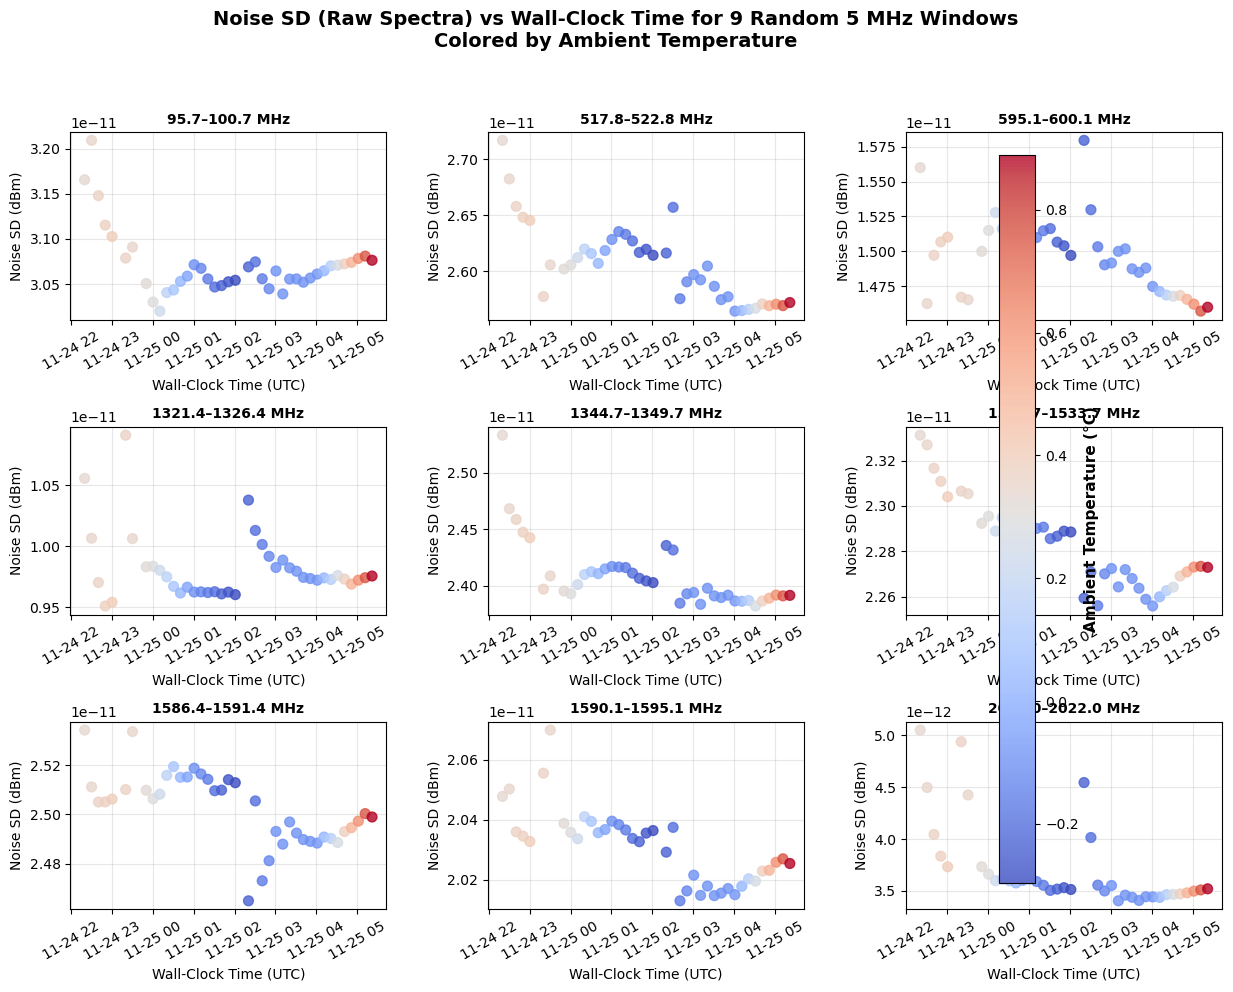

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import requests
import pandas as pd
import random

# -----------------------------
# PARAMETERS
# -----------------------------
MHz_window = 5.0
n_windows = 9
max_lines = 40

first_time = all_elapsed_times[0]
F_full = data_by_time[first_time]['F']
f_min = F_full.min()
f_max = F_full.max() - MHz_window

random_starts = sorted(random.sample(list(np.linspace(f_min, f_max, 2000)), n_windows))
ncols = int(np.ceil(np.sqrt(n_windows)))
nrows = int(np.ceil(n_windows / ncols))

if len(all_elapsed_times) > max_lines:
    step = len(all_elapsed_times) // max_lines
    plot_times = all_elapsed_times[::step]
else:
    plot_times = all_elapsed_times

# -----------------------------
# FETCH AMBIENT TEMPERATURE (Open-Meteo)
# -----------------------------
lat, lon = 42.3732, -71.1187  # Harvard, Cambridge MA
t_start = min([entry['timestamp'] for entry in data_by_time.values()]).strftime("%Y-%m-%d")
t_end   = max([entry['timestamp'] for entry in data_by_time.values()]).strftime("%Y-%m-%d")

url = (
    f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={t_start}&end_date={t_end}"
    "&hourly=temperature_2m&timezone=UTC"
)
resp = requests.get(url, timeout=30)
resp.raise_for_status()
data = resp.json()

temp_times = pd.to_datetime(data["hourly"]["time"], utc=True).to_pydatetime()
temp_vals = np.array(data["hourly"]["temperature_2m"])

# -----------------------------
# PREPARE GRID PLOT
# -----------------------------
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows), sharey=False)
axes = axes.flatten()

norm = Normalize(vmin=min(temp_vals), vmax=max(temp_vals))

# -----------------------------
# PLOT EACH RANDOM 5 MHz WINDOW (RAW SPECTRA SD)
# -----------------------------
for ax, f0 in zip(axes, random_starts):
    f1 = f0 + MHz_window
    noise_std_window = []
    noise_times_dt = []

    # Compute SD in window per timestamp (RAW spectrum)
    for t in plot_times:
        entry = data_by_time[t]
        F = entry['F']
        spec = entry['spec']          # raw spectrum before baseline/gain
        ts_dt = entry['timestamp']

        mask = (F >= f0) & (F <= f1)
        if mask.sum() < 5:
            continue

        noise_std_window.append(np.std(spec[mask]))
        noise_times_dt.append(ts_dt)

    noise_std_window = np.array(noise_std_window)
    noise_times_dt = np.array(noise_times_dt)

    # Interpolate temperature onto timestamps
    temp_interp = np.interp(
        [dt.timestamp() for dt in noise_times_dt],
        [dt.timestamp() for dt in temp_times],
        temp_vals
    )

    # Scatter plot colored by temperature
    sc = ax.scatter(
        noise_times_dt,
        noise_std_window,
        c=temp_interp,
        cmap="coolwarm",
        s=50,
        alpha=0.8,
        zorder=3
    )

    ax.set_title(f"{f0:.1f}–{f1:.1f} MHz", fontsize=10, fontweight="bold")
    ax.set_xlabel("Wall-Clock Time (UTC)", fontsize=10)
    ax.set_ylabel("Noise SD (dBm)", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

for ax in axes[len(random_starts):]:
    ax.axis('off')

# Add a single colorbar for the whole figure
cbar = fig.colorbar(sc, ax=axes.tolist(), location="right", pad=0.02, shrink=0.9)
cbar.set_label("Ambient Temperature (°C)", fontsize=11, fontweight="bold")

fig.suptitle("Noise SD (Raw Spectra) vs Wall-Clock Time for 9 Random 5 MHz Windows\nColored by Ambient Temperature",
             fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0.04, 0.04, 0.96, 0.95])
plt.show()


In [31]:
import numpy as np

# ------------------------------------------------------------
# REBUILD plot_times IF IT DOESN'T EXIST
# ------------------------------------------------------------
if "plot_times" not in globals():
    plot_times = sorted(baseline_sub_specs.keys())
    print(f"[INFO] plot_times not found — rebuilt from baseline_sub_specs "
          f"({len(plot_times)} entries)")

# ------------------------------------------------------------
# COMPUTE GAIN CORRECTION FACTORS
# ------------------------------------------------------------
gain_change_by_time = {}

for t in plot_times:
    residuals = baseline_sub_specs[t]
    scaled = gain_norm_specs[t]

    scales = []

    for r, r_scaled in zip(residuals, scaled):
        var_before = np.var(r)
        var_after  = np.var(r_scaled)

        if var_before > 0:
            scale_factor = np.sqrt(var_after / var_before)
        else:
            scale_factor = np.nan

        scales.append(scale_factor)

    scales = np.array(scales)

    gain_change_by_time[t] = {
        "mean_scale":   np.nanmean(scales),
        "median_scale": np.nanmedian(scales),
        "min_scale":    np.nanmin(scales),
        "max_scale":    np.nanmax(scales),
        "scales":       scales
    }

# ------------------------------------------------------------
# GLOBAL SUMMARY
# ------------------------------------------------------------
all_scales = np.concatenate(
    [gain_change_by_time[t]["scales"] for t in plot_times]
)

global_mean   = np.nanmean(all_scales)
global_median = np.nanmedian(all_scales)
global_min    = np.nanmin(all_scales)
global_max    = np.nanmax(all_scales)

print("\n" + "="*70)
print("GAIN NORMALIZATION CHANGE SUMMARY")
print("="*70)
print(f"Global mean scale factor:   {global_mean:.4f}")
print(f"Global median scale factor: {global_median:.4f}")
print(f"Global min scale factor:    {global_min:.4f}")
print(f"Global max scale factor:    {global_max:.4f}")
print("="*70)

# ------------------------------------------------------------
# PER-TIME PRINT TABLE
# ------------------------------------------------------------
print("\nPer-time gain correction factors:")
print(f"{'Time (s)':>10} | {'Mean':>8} | {'Median':>8} | {'Min':>8} | {'Max':>8}")
print("-"*55)

for t in plot_times:
    stats = gain_change_by_time[t]
    print(f"{t:10.1f} | "
          f"{stats['mean_scale']:8.4f} | "
          f"{stats['median_scale']:8.4f} | "
          f"{stats['min_scale']:8.4f} | "
          f"{stats['max_scale']:8.4f}")

# ------------------------------------------------------------
# SINGLE QUOTABLE NUMBER
# ------------------------------------------------------------
gain_change_factor = global_median

print("\n" + "="*70)
print(f"QUOTABLE GAIN CHANGE FACTOR (median): {gain_change_factor:.4f}×")
print("="*70)



GAIN NORMALIZATION CHANGE SUMMARY
Global mean scale factor:   260780491066.3832
Global median scale factor: 263956555976.2006
Global min scale factor:    74183064950.9051
Global max scale factor:    481610589005.3528

Per-time gain correction factors:
  Time (s) |     Mean |   Median |      Min |      Max
-------------------------------------------------------
     602.0 | 95616126383.1360 | 96733381622.3727 | 74183064950.9051 | 117043717220.6561
     607.0 | 93552668432.8954 | 95472208144.5096 | 78816994689.4218 | 106971539076.7991
     608.0 | 95485429874.9325 | 91167678337.6122 | 79148757157.7045 | 117371780268.7719
    1206.0 | 134550587239.4194 | 132698673114.6958 | 109392029435.3850 | 165013019558.3797
    1208.0 | 132165245770.9313 | 129678128310.4807 | 107175853080.1057 | 161221150233.4413
    1215.0 | 133169482094.6600 | 133337860761.9277 | 110931732395.2525 | 157520705504.3452
    1811.0 | 166237516614.3832 | 166358313002.5135 | 138271691029.0896 | 202011252488.9580
    1817